# SSURGO PPKX to AOI Pixel Dataset with ESD Site Potential

This ArcGIS Pro / ArcPy notebook extracts SSURGO `.ppkx` packages, finds the packaged SSURGO mapunit polygons and relational tables, clips them to NCA and RCEW, rasterizes `MUKEY` to each 10 m AOI grid, and joins ecological-site potential from the 2026 ESD index.

Primary linkage:

```text
pixel → MUKEY → component.MUKEY → component.COKEY → coecoclass.COKEY → ECOCLASSID → esd_index_2026.ecoclassid
```

Interpretation:

```text
{AOI}_ssurgo_mukey_10m
```

is the stable per-pixel SSURGO key raster. Ecological-site/site-potential fields are attached through the dominant component table and preserved in a weighted component/ecoclass table.

## 1. Imports and paths

In [1]:

import arcpy
from pathlib import Path
import shutil
import csv
import json
import urllib.parse
import urllib.request
import xml.etree.ElementTree as ET

arcpy.env.overwriteOutput = True

# ---------------------------------------------------------------------
# Shared PPKX input directory
# ---------------------------------------------------------------------
PPKX_DIR = Path(r"C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX")

PPKX_FILES = [
    PPKX_DIR / "Bruneau_17050102.ppkx",
    PPKX_DIR / "MiddleSnakeSuccor_17050103.ppkx",
    PPKX_DIR / "CJStrikeReservoir_17050101.ppkx",
    PPKX_DIR / "LowerBoise_17050114.ppkx",
]

# ---------------------------------------------------------------------
# ESD index / site-potential lookup
# Expected columns:
# database_year, mlra_symbol, mlra_name, catalog_site_id, ecoclassid,
# site_name, site_text_raw, site_context_text, site_url, mlra_url
# ---------------------------------------------------------------------
ESD_INDEX_CSV = Path(r"C:\NCA_DATA\Ancillary_Data\NRCS ESDs\2026\tables\esd_index_2026.csv")

# ---------------------------------------------------------------------
# AOI-specific inputs and outputs
# ---------------------------------------------------------------------
AOIS = {
    "NCA": {
        "aoi_fc": r"C:\NCA_DATA\templates\NCA_NAD83UTM11N.shp",
        "reference_raster": r"C:\NCA_DATA\templates\grid_template_10m_26911_uint8.tif",
        "ssurgo_dir": Path(r"C:\NCA_DATA\Ancillary_Data\SSURGO"),
        "out_gdb": r"C:\NCA_DATA\Ancillary_Data\SSURGO\NCA_SSURGO_10m.gdb",
    },
    "RCEW": {
        "aoi_fc": r"A:\RCEW_DATA\Templates\RCEW_shapefile\RCEW_extent_26911.shp",
        "reference_raster": r"A:\RCEW_DATA\template_grid\RCEW_template_grid_26911_10m.tif",
        "ssurgo_dir": Path(r"A:\RCEW_DATA\Ancillary_Data\SSURGO"),
        "out_gdb": r"A:\RCEW_DATA\Ancillary_Data\SSURGO\RCEW_SSURGO_10m.gdb",
    },
}

# Extraction cache and scratch workspace.
EXTRACT_DIR = Path(r"C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED")
SCRATCH_GDB = r"C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_scratch.gdb"

# Set True only if you want to delete and recreate the extracted package folders.
FORCE_REEXTRACT = False

for p in PPKX_FILES:
    print(p)

print("ESD index:", ESD_INDEX_CSV)

C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX\Bruneau_17050102.ppkx
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX\MiddleSnakeSuccor_17050103.ppkx
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX\CJStrikeReservoir_17050101.ppkx
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX\LowerBoise_17050114.ppkx
ESD index: C:\NCA_DATA\Ancillary_Data\NRCS ESDs\2026\tables\esd_index_2026.csv


## 2. Small helper functions

In [2]:

def ensure_gdb(gdb_path):
    gdb_path = Path(gdb_path)
    gdb_path.parent.mkdir(parents=True, exist_ok=True)
    if not arcpy.Exists(str(gdb_path)):
        print(f"Creating geodatabase: {gdb_path}")
        arcpy.management.CreateFileGDB(str(gdb_path.parent), gdb_path.name)
    return str(gdb_path)


def delete_if_exists(path):
    if arcpy.Exists(path):
        arcpy.management.Delete(path)


def list_fields_upper(dataset):
    return {f.name.upper(): f.name for f in arcpy.ListFields(dataset)}


def actual_field(dataset, requested_name, required=True):
    fields = list_fields_upper(dataset)
    key = requested_name.upper()

    if key in fields:
        return fields[key]

    if required:
        raise ValueError(
            f"Required field '{requested_name}' not found in {dataset}. "
            f"Available fields: {list(fields.values())}"
        )

    return None


def has_field(dataset, requested_name):
    return actual_field(dataset, requested_name, required=False) is not None


def get_count(dataset):
    return int(arcpy.management.GetCount(dataset)[0])


def safe_name(text, max_len=55):
    out = "".join(ch if ch.isalnum() or ch == "_" else "_" for ch in str(text)).strip("_")
    return (out or "unnamed")[:max_len]


def path_in_gdb(gdb, name):
    return str(Path(gdb) / safe_name(name))


def find_gdbs(root):
    return list(Path(root).rglob("*.gdb"))


def list_feature_classes_in_gdb(gdb):
    arcpy.env.workspace = str(gdb)
    fcs = []

    for ds in arcpy.ListDatasets(feature_type="feature") or []:
        arcpy.env.workspace = str(Path(gdb) / ds)
        for fc in arcpy.ListFeatureClasses() or []:
            fcs.append(str(Path(gdb) / ds / fc))

    arcpy.env.workspace = str(gdb)
    for fc in arcpy.ListFeatureClasses() or []:
        fcs.append(str(Path(gdb) / fc))

    return fcs


def list_tables_in_gdb(gdb):
    arcpy.env.workspace = str(gdb)
    return [str(Path(gdb) / t) for t in (arcpy.ListTables() or [])]


def unique_values(table, field):
    field = actual_field(table, field)
    vals = set()
    with arcpy.da.SearchCursor(table, [field]) as cur:
        for (v,) in cur:
            if v not in (None, "", " "):
                vals.add(str(v))
    return vals


def sql_in_chunks(table, field, values, chunk_size=900):
    values = [str(v) for v in values if v not in (None, "", " ")]
    if not values:
        raise ValueError(f"No values available for SQL selection on {field}")

    workspace = arcpy.Describe(table).path
    delim = arcpy.AddFieldDelimiters(workspace, field)
    clauses = []

    for i in range(0, len(values), chunk_size):
        chunk = values[i:i + chunk_size]
        quoted = ",".join("'" + str(v).replace("'", "''") + "'" for v in chunk)
        clauses.append(f"{delim} IN ({quoted})")

    return " OR ".join(clauses)


def copy_selected_table_by_values(in_table, out_table, field, values):
    field_actual = actual_field(in_table, field)
    delete_if_exists(out_table)
    where = sql_in_chunks(in_table, field_actual, values)
    arcpy.conversion.ExportTable(in_table, out_table, where)
    return out_table


def delete_identical_if_fields_exist(dataset, fields):
    existing = list_fields_upper(dataset)
    use_fields = []
    for f in fields:
        if f.upper() == "SHAPE":
            use_fields.append("Shape")
        elif f.upper() in existing:
            use_fields.append(existing[f.upper()])

    if use_fields:
        arcpy.management.DeleteIdentical(dataset, use_fields)


def find_table_by_name_or_fields(gdb, preferred_names, required_fields=None):
    preferred_names = [n.lower() for n in preferred_names]
    required_fields = required_fields or []
    matches = []

    for tbl in list_tables_in_gdb(gdb):
        name = Path(tbl).name.lower()
        if name in preferred_names and all(has_field(tbl, f) for f in required_fields):
            matches.append(tbl)

    if matches:
        return matches

    for tbl in list_tables_in_gdb(gdb):
        if all(has_field(tbl, f) for f in required_fields):
            matches.append(tbl)

    return matches


def find_mupolygon_feature_classes(gdb):
    candidates = []
    for fc in list_feature_classes_in_gdb(gdb):
        try:
            desc = arcpy.Describe(fc)
            lname = Path(fc).name.lower()
            if desc.shapeType == "Polygon" and has_field(fc, "MUKEY"):
                if "mupolygon" in lname or "mapunit" in lname or has_field(fc, "AREASYMBOL"):
                    candidates.append(fc)
        except Exception:
            pass
    return candidates

## 2b. Soil Data Access fallback for missing local SSURGO tables

If the PPKX contains only spatial mapunit polygons, this section retrieves `component` and `coecoclass` records from USDA-NRCS Soil Data Access using the clipped AOI `MUKEY`s.


In [3]:
SDA_POST_URL = "https://sdmdataaccess.nrcs.usda.gov/Tabular/post.rest"


def parse_sda_xml(raw):
    """
    Parse SDA XML response of the form:

    <NewDataSet>
      <Table>
        <mukey>...</mukey>
        <cokey>...</cokey>
        ...
      </Table>
      <Table>...</Table>
    </NewDataSet>

    Ignores the embedded xs:schema block.
    """
    root = ET.fromstring(raw)

    records = []

    # SDA XML here has no namespace on Table elements, but this is defensive.
    for table in root.findall(".//Table"):
        rec = {}
        for child in list(table):
            # Skip schema elements if encountered.
            tag = child.tag.split("}", 1)[-1] if "}" in child.tag else child.tag
            rec[tag] = child.text
        if rec:
            records.append(rec)

    return records


def parse_sda_response(raw):
    """
    SDA can return JSON or XML depending on service behavior.
    This function accepts both.
    """
    raw_strip = raw.lstrip()

    if raw_strip.startswith("<"):
        return parse_sda_xml(raw)

    data = json.loads(raw)

    if isinstance(data, dict) and "Exception" in data:
        raise RuntimeError(f"SDA query exception: {data['Exception']}")

    table = data.get("Table", [])
    if not table:
        return []

    # JSON shape may be:
    # {"Table": [[col1, col2, ...], [row1val1, row1val2, ...], ...]}
    if isinstance(table, list) and table and isinstance(table[0], list):
        columns = table[0]
        return [dict(zip(columns, row)) for row in table[1:]]

    # Some SDA JSON responses may be:
    # {"Table": [{"field": "value"}, ...]}
    if isinstance(table, list) and table and isinstance(table[0], dict):
        return table

    return []


def sda_run_query(sql):
    """
    Submit SQL to USDA-NRCS Soil Data Access Tabular REST endpoint.

    The service may return XML even when JSON is requested. The parser accepts both.
    """
    body = json.dumps({"query": sql}).encode("utf-8")

    req = urllib.request.Request(
        SDA_POST_URL,
        data=body,
        method="POST",
        headers={
            "Content-Type": "application/json",
            "Accept": "application/json",
            "User-Agent": "ArcPy-SSURGO-SDA-query"
        }
    )

    with urllib.request.urlopen(req, timeout=180) as resp:
        raw = resp.read().decode("utf-8", errors="replace")

    try:
        return parse_sda_response(raw)
    except Exception:
        print("Could not parse SDA response. First 1000 characters:")
        print(raw[:1000])
        raise


def chunked(values, n=250):
    """
    Conservative chunking keeps SDA requests manageable.
    """
    values = [str(v) for v in values if v not in (None, "", " ")]
    for i in range(0, len(values), n):
        yield values[i:i+n]


def sql_quote_list(values):
    return ",".join("'" + str(v).replace("'", "''") + "'" for v in values)


def make_table_from_records(out_gdb, out_name, records, field_specs):
    """
    field_specs:
      [(field_name, field_type, field_length_or_None), ...]

    Field names in records may be lower/upper/mixed. This function uses
    case-insensitive lookup.
    """
    out_table = path_in_gdb(out_gdb, out_name)
    delete_if_exists(out_table)

    arcpy.management.CreateTable(out_gdb, Path(out_table).name)

    for field_name, field_type, field_length in field_specs:
        if field_type.upper() == "TEXT":
            arcpy.management.AddField(out_table, field_name, field_type, field_length=field_length or 255)
        else:
            arcpy.management.AddField(out_table, field_name, field_type)

    fields = [f[0] for f in field_specs]

    with arcpy.da.InsertCursor(out_table, fields) as cur:
        for rec in records:
            rec_ci = {str(k).lower(): v for k, v in rec.items()}

            row = []
            for field_name, field_type, _ in field_specs:
                val = rec_ci.get(field_name.lower())

                if val in ("", "NULL", "None"):
                    val = None

                if val is not None and field_type.upper() in ("LONG", "DOUBLE", "FLOAT"):
                    try:
                        val = float(val)
                        if field_type.upper() == "LONG":
                            val = int(val)
                    except Exception:
                        val = None

                row.append(val)

            cur.insertRow(row)

    return out_table


def query_sda_component_by_mukeys(mukeys, out_gdb, out_name):
    records = []
    mukeys = sorted(mukeys)

    print(f"Querying SDA component table for {len(mukeys)} MUKEYs...")

    for i, chunk in enumerate(chunked(mukeys, n=250), start=1):
        sql = f"""
        SELECT
            mukey,
            cokey,
            compname,
            comppct_r,
            majcompflag
        FROM component
        WHERE mukey IN ({sql_quote_list(chunk)})
        """
        chunk_records = sda_run_query(sql)
        records.extend(chunk_records)
        print(f"  component chunk {i}: {len(chunk_records)} rows")

    field_specs = [
        ("mukey", "TEXT", 30),
        ("cokey", "TEXT", 30),
        ("compname", "TEXT", 255),
        ("comppct_r", "DOUBLE", None),
        ("majcompflag", "TEXT", 10),
    ]

    out_table = make_table_from_records(out_gdb, out_name, records, field_specs)

    for old, new in [("mukey", "MUKEY"), ("cokey", "COKEY"), ("compname", "COMPNAME"),
                     ("comppct_r", "COMPPCT_R"), ("majcompflag", "MAJCOMPFLAG")]:
        if has_field(out_table, old) and not has_field(out_table, new):
            arcpy.management.AlterField(out_table, old, new, new)

    return out_table


def query_sda_coecoclass_by_cokeys(cokeys, out_gdb, out_name):
    records = []
    cokeys = sorted(cokeys)

    print(f"Querying SDA coecoclass table for {len(cokeys)} COKEYs...")

    for i, chunk in enumerate(chunked(cokeys, n=250), start=1):
        sql = f"""
        SELECT
            coecoclasskey,
            cokey,
            ecoclassid,
            ecoclassname
        FROM coecoclass
        WHERE cokey IN ({sql_quote_list(chunk)})
        """
        chunk_records = sda_run_query(sql)
        records.extend(chunk_records)
        print(f"  coecoclass chunk {i}: {len(chunk_records)} rows")

    field_specs = [
        ("coecoclasskey", "TEXT", 30),
        ("cokey", "TEXT", 30),
        ("ecoclassid", "TEXT", 80),
        ("ecoclassname", "TEXT", 255),
    ]

    out_table = make_table_from_records(out_gdb, out_name, records, field_specs)

    for old, new in [("coecoclasskey", "COECOCLASSKEY"), ("cokey", "COKEY"),
                     ("ecoclassid", "ECOCLASSID"), ("ecoclassname", "ECOCLASSNAME")]:
        if has_field(out_table, old) and not has_field(out_table, new):
            arcpy.management.AlterField(out_table, old, new, new)

    return out_table


# Smoke test. Leave this as True until SDA query succeeds once.
RUN_SDA_SMOKE_TEST = True

if RUN_SDA_SMOKE_TEST:
    test_sql = """
    SELECT TOP 1
        mukey,
        cokey,
        compname,
        comppct_r,
        majcompflag
    FROM component
    WHERE mukey IS NOT NULL
    """
    test_rows = sda_run_query(test_sql)
    print("SDA smoke test rows:", len(test_rows))
    if test_rows:
        print(test_rows[0])

SDA smoke test rows: 1
{'mukey': '50104', 'cokey': '27406778', 'compname': 'Kupreanof', 'comppct_r': '50', 'majcompflag': 'Yes'}


## 3. Validate inputs and create workspaces

In [4]:

missing_ppkx = [str(p) for p in PPKX_FILES if not p.exists()]
if missing_ppkx:
    raise FileNotFoundError("Missing PPKX files:\n" + "\n".join(missing_ppkx))

if not ESD_INDEX_CSV.exists():
    raise FileNotFoundError(f"Missing ESD index CSV: {ESD_INDEX_CSV}")

for aoi_name, cfg in AOIS.items():
    if not arcpy.Exists(cfg["aoi_fc"]):
        raise FileNotFoundError(f"{aoi_name} AOI not found: {cfg['aoi_fc']}")
    if not arcpy.Exists(cfg["reference_raster"]):
        raise FileNotFoundError(f"{aoi_name} reference raster not found: {cfg['reference_raster']}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
ensure_gdb(SCRATCH_GDB)

for aoi_name, cfg in AOIS.items():
    cfg["ssurgo_dir"].mkdir(parents=True, exist_ok=True)
    ensure_gdb(cfg["out_gdb"])

print("Input validation complete.")

Input validation complete.


## 4. Read the ESD index lookup

In [5]:

def normalize_key(x):
    if x is None:
        return None
    x = str(x).strip()
    if not x:
        return None
    return x.upper()


def read_esd_index(csv_path):
    required = ["ecoclassid"]
    lookup = {}

    with open(csv_path, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        headers = [h.strip() for h in reader.fieldnames or []]
        lower_to_actual = {h.lower(): h for h in headers}

        for col in required:
            if col not in lower_to_actual:
                raise ValueError(f"Missing required ESD index column '{col}'. Found: {headers}")

        for row in reader:
            rec = {k.lower().strip(): v for k, v in row.items()}
            key = normalize_key(rec.get("ecoclassid"))
            if not key:
                continue

            # First record wins if duplicates exist.
            lookup.setdefault(key, {
                "ESD_DATABASE_YEAR": rec.get("database_year"),
                "ESD_MLRA_SYMBOL": rec.get("mlra_symbol"),
                "ESD_MLRA_NAME": rec.get("mlra_name"),
                "ESD_CATALOG_SITE_ID": rec.get("catalog_site_id"),
                "ESD_ECOCLASSID": rec.get("ecoclassid"),
                "ESD_SITE_NAME": rec.get("site_name"),
                "ESD_SITE_TEXT_RAW": rec.get("site_text_raw"),
                "ESD_SITE_CONTEXT_TEXT": rec.get("site_context_text"),
                "ESD_SITE_URL": rec.get("site_url"),
                "ESD_MLRA_URL": rec.get("mlra_url"),
            })

    return lookup


ESD_LOOKUP = read_esd_index(ESD_INDEX_CSV)

print("ESD records loaded:", len(ESD_LOOKUP))
print("Example:")
for i, (k, v) in enumerate(ESD_LOOKUP.items()):
    print(k, v)
    if i >= 2:
        break

ESD records loaded: 8723
Example:
F001XA001WA {'ESD_DATABASE_YEAR': '2026', 'ESD_MLRA_SYMBOL': '001X', 'ESD_MLRA_NAME': 'Northern Pacific Coast Range, Foothills, and Valleys', 'ESD_CATALOG_SITE_ID': 'AX001X01X001', 'ESD_ECOCLASSID': 'F001XA001WA', 'ESD_SITE_NAME': 'Temperate Flood Plain Shrubland', 'ESD_SITE_TEXT_RAW': 'AX001X01X001/F001XA001WA Temperate Flood Plain Shrubland', 'ESD_SITE_CONTEXT_TEXT': 'Provisional AX001X01X001/F001XA001WA Temperate Flood Plain Shrubland', 'ESD_SITE_URL': 'https://edit.sc.egov.usda.gov/catalogs/esd/001X/AX001X01X001', 'ESD_MLRA_URL': 'https://edit.sc.egov.usda.gov/catalogs/esd/001X'}
F001XA002WA {'ESD_DATABASE_YEAR': '2026', 'ESD_MLRA_SYMBOL': '001X', 'ESD_MLRA_NAME': 'Northern Pacific Coast Range, Foothills, and Valleys', 'ESD_CATALOG_SITE_ID': 'AX001X01X002', 'ESD_ECOCLASSID': 'F001XA002WA', 'ESD_SITE_NAME': 'Mesic Udic Flood Plain Forest', 'ESD_SITE_TEXT_RAW': 'AX001X01X002/F001XA002WA Mesic Udic Flood Plain Forest', 'ESD_SITE_CONTEXT_TEXT': 'Provis

## 5. Extract PPKX packages

In [6]:

def extract_ppkx_packages(ppkx_files, extract_dir, force=False):
    extracted_roots = []

    for ppkx in ppkx_files:
        target = extract_dir / ppkx.stem
        extracted_roots.append(target)

        if target.exists() and not force:
            print(f"Using existing extraction: {target}")
            continue

        if target.exists() and force:
            shutil.rmtree(target)

        target.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {ppkx.name}")
        arcpy.management.ExtractPackage(str(ppkx), str(target))

    return extracted_roots


EXTRACTED_ROOTS = extract_ppkx_packages(PPKX_FILES, EXTRACT_DIR, force=FORCE_REEXTRACT)

for root in EXTRACTED_ROOTS:
    print(root)

Using existing extraction: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\Bruneau_17050102
Using existing extraction: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\MiddleSnakeSuccor_17050103
Using existing extraction: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\CJStrikeReservoir_17050101
Using existing extraction: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\LowerBoise_17050114
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\Bruneau_17050102
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\MiddleSnakeSuccor_17050103
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\CJStrikeReservoir_17050101
C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\LowerBoise_17050114


## 6. Discover SSURGO mapunit polygons and relationship tables

In [7]:

def discover_ssurgo_sources(extracted_roots):
    sources = []

    for root in extracted_roots:
        gdbs = find_gdbs(root)
        print(f"{root.name}: {len(gdbs)} geodatabases")

        for gdb in gdbs:
            mupolys = find_mupolygon_feature_classes(gdb)

            component_tables = find_table_by_name_or_fields(
                gdb,
                preferred_names=["component"],
                required_fields=["MUKEY", "COKEY"]
            )

            coecoclass_tables = find_table_by_name_or_fields(
                gdb,
                preferred_names=["coecoclass"],
                required_fields=["COKEY"]
            )

            if mupolys:
                sources.append({
                    "package_root": str(root),
                    "gdb": str(gdb),
                    "mupolygons": mupolys,
                    "component": component_tables[0] if component_tables else None,
                    "coecoclass": coecoclass_tables[0] if coecoclass_tables else None,
                })

    return sources


SSURGO_SOURCES = discover_ssurgo_sources(EXTRACTED_ROOTS)

if not SSURGO_SOURCES:
    raise RuntimeError("No SSURGO polygon sources were discovered.")

for i, src in enumerate(SSURGO_SOURCES, start=1):
    print("\nSource", i)
    print("GDB:", src["gdb"])
    print("MUPOLYGON:")
    for fc in src["mupolygons"]:
        print("  ", fc, get_count(fc))
    print("Component:", src["component"])
    print("Coecoclass:", src["coecoclass"])

Bruneau_17050102: 1 geodatabases
MiddleSnakeSuccor_17050103: 1 geodatabases
CJStrikeReservoir_17050101: 1 geodatabases
LowerBoise_17050114: 1 geodatabases

Source 1
GDB: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\Bruneau_17050102\commondata\bruneau_17050102.gdb
MUPOLYGON:
   C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\Bruneau_17050102\commondata\bruneau_17050102.gdb\Mapunits 2591
Component: None
Coecoclass: None

Source 2
GDB: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\MiddleSnakeSuccor_17050103\commondata\middlesnakesuccor_17050103.gdb
MUPOLYGON:
   C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\MiddleSnakeSuccor_17050103\commondata\middlesnakesuccor_17050103.gdb\Mapunits 7894
Component: None
Coecoclass: None

Source 3
GDB: C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\CJStrikeReservoir_17050101\commondata\cjstrikereservoir_17050101.gdb
MUPOLYGON:
   C:\NCA_DATA\Ancillary_Data\SSURGO\SSURGO_PPKX_EXTRACTED\CJStrikeReservoir_17050

## 7. Merge all HUC SSURGO polygons and tables

In [8]:
ALL_MUPOLYGON_RAW = path_in_gdb(SCRATCH_GDB, "ssurgo_all_hucs_mupolygon_raw")
ALL_MUPOLYGON = path_in_gdb(SCRATCH_GDB, "ssurgo_all_hucs_mupolygon")

mupolygon_inputs = []
for src in SSURGO_SOURCES:
    mupolygon_inputs.extend(src["mupolygons"])

delete_if_exists(ALL_MUPOLYGON_RAW)
arcpy.management.Merge(mupolygon_inputs, ALL_MUPOLYGON_RAW)
arcpy.management.RepairGeometry(ALL_MUPOLYGON_RAW)

delete_if_exists(ALL_MUPOLYGON)
arcpy.management.CopyFeatures(ALL_MUPOLYGON_RAW, ALL_MUPOLYGON)
delete_identical_if_fields_exist(ALL_MUPOLYGON, ["Shape", "MUKEY"])

print("Merged MUPOLYGON rows:", get_count(ALL_MUPOLYGON))


component_inputs = [src["component"] for src in SSURGO_SOURCES if src["component"]]
ALL_COMPONENT = None

if component_inputs:
    ALL_COMPONENT = path_in_gdb(SCRATCH_GDB, "ssurgo_all_hucs_component")
    delete_if_exists(ALL_COMPONENT)
    arcpy.management.Merge(component_inputs, ALL_COMPONENT)
    delete_identical_if_fields_exist(ALL_COMPONENT, ["COKEY"])
    print("Merged local component rows:", get_count(ALL_COMPONENT))
else:
    print("No local component tables found in the PPKX extraction. Will query SDA after AOI clipping.")


coecoclass_inputs = [src["coecoclass"] for src in SSURGO_SOURCES if src["coecoclass"]]
ALL_COECOCLASS = None

if coecoclass_inputs:
    ALL_COECOCLASS = path_in_gdb(SCRATCH_GDB, "ssurgo_all_hucs_coecoclass")
    delete_if_exists(ALL_COECOCLASS)
    arcpy.management.Merge(coecoclass_inputs, ALL_COECOCLASS)

    if has_field(ALL_COECOCLASS, "COECOCLASSKEY"):
        delete_identical_if_fields_exist(ALL_COECOCLASS, ["COECOCLASSKEY"])
    else:
        delete_identical_if_fields_exist(ALL_COECOCLASS, ["COKEY", "ECOCLASSID"])

    print("Merged local coecoclass rows:", get_count(ALL_COECOCLASS))
else:
    print("No local coecoclass tables found in the PPKX extraction. Will query SDA after AOI component retrieval.")

Merged MUPOLYGON rows: 25958
No local component tables found in the PPKX extraction. Will query SDA after AOI clipping.
No local coecoclass tables found in the PPKX extraction. Will query SDA after AOI component retrieval.


## 8. Clip SSURGO polygons to AOIs

In [9]:

def prepare_aoi_geometry(aoi_name, cfg):
    out_gdb = cfg["out_gdb"]
    aoi_fc = cfg["aoi_fc"]
    ref_raster = cfg["reference_raster"]

    ref_sr = arcpy.Describe(ref_raster).spatialReference
    aoi_sr = arcpy.Describe(aoi_fc).spatialReference
    out_aoi = path_in_gdb(out_gdb, f"{aoi_name}_aoi_for_ssurgo")

    delete_if_exists(out_aoi)

    if aoi_sr and ref_sr and aoi_sr.factoryCode == ref_sr.factoryCode:
        arcpy.management.CopyFeatures(aoi_fc, out_aoi)
    else:
        arcpy.management.Project(aoi_fc, out_aoi, ref_sr)

    arcpy.management.RepairGeometry(out_aoi)
    return out_aoi


def clip_ssurgo_to_aoi(aoi_name, cfg):
    aoi_clip_fc = prepare_aoi_geometry(aoi_name, cfg)
    out_fc = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_mupolygon")

    delete_if_exists(out_fc)
    arcpy.analysis.Clip(ALL_MUPOLYGON, aoi_clip_fc, out_fc)
    arcpy.management.RepairGeometry(out_fc)

    if not has_field(out_fc, "clip_area_m2"):
        arcpy.management.AddField(out_fc, "clip_area_m2", "DOUBLE")

    arcpy.management.CalculateGeometryAttributes(
        out_fc,
        [["clip_area_m2", "AREA_GEODESIC"]],
        area_unit="SQUARE_METERS"
    )

    return out_fc


AOI_MUPOLYGONS = {}

for aoi_name, cfg in AOIS.items():
    AOI_MUPOLYGONS[aoi_name] = clip_ssurgo_to_aoi(aoi_name, cfg)
    print(aoi_name, "clipped polygon rows:", get_count(AOI_MUPOLYGONS[aoi_name]))

NCA clipped polygon rows: 5032
RCEW clipped polygon rows: 171


## 9. Subset component and coecoclass tables to each AOI

In [10]:
def make_aoi_component_and_coecoclass_tables(aoi_name, cfg, aoi_mupolygon):
    mukeys = unique_values(aoi_mupolygon, "MUKEY")
    print(aoi_name, "unique clipped MUKEYs:", len(mukeys))

    comp_out = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_component_table")

    if ALL_COMPONENT:
        copy_selected_table_by_values(ALL_COMPONENT, comp_out, "MUKEY", mukeys)
        print(aoi_name, "component source: local PPKX/GDB table")
    else:
        comp_out = query_sda_component_by_mukeys(
            mukeys,
            cfg["out_gdb"],
            f"{aoi_name}_ssurgo_component_table"
        )
        print(aoi_name, "component source: SDA query")

    cokeys = unique_values(comp_out, "COKEY")
    print(aoi_name, "unique COKEYs:", len(cokeys))

    eco_out = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_coecoclass_table")

    if ALL_COECOCLASS:
        copy_selected_table_by_values(ALL_COECOCLASS, eco_out, "COKEY", cokeys)
        print(aoi_name, "coecoclass source: local PPKX/GDB table")
    else:
        eco_out = query_sda_coecoclass_by_cokeys(
            cokeys,
            cfg["out_gdb"],
            f"{aoi_name}_ssurgo_coecoclass_table"
        )
        print(aoi_name, "coecoclass source: SDA query")

    return comp_out, eco_out


AOI_TABLES = {}

for aoi_name, cfg in AOIS.items():
    comp, eco = make_aoi_component_and_coecoclass_tables(aoi_name, cfg, AOI_MUPOLYGONS[aoi_name])
    AOI_TABLES[aoi_name] = {"component": comp, "coecoclass": eco}

    print("\n", aoi_name)
    print("Unique MUKEYs:", len(unique_values(AOI_MUPOLYGONS[aoi_name], "MUKEY")))
    print("Component rows:", get_count(comp))
    print("Coecoclass rows:", get_count(eco))

NCA unique clipped MUKEYs: 387
Querying SDA component table for 387 MUKEYs...
  component chunk 1: 389 rows
  component chunk 2: 211 rows
NCA component source: SDA query
NCA unique COKEYs: 600
Querying SDA coecoclass table for 600 COKEYs...
  coecoclass chunk 1: 226 rows
  coecoclass chunk 2: 230 rows
  coecoclass chunk 3: 85 rows
NCA coecoclass source: SDA query

 NCA
Unique MUKEYs: 387
Component rows: 600
Coecoclass rows: 541
RCEW unique clipped MUKEYs: 43
Querying SDA component table for 43 MUKEYs...
  component chunk 1: 111 rows
RCEW component source: SDA query
RCEW unique COKEYs: 111
Querying SDA coecoclass table for 111 COKEYs...
  coecoclass chunk 1: 94 rows
RCEW coecoclass source: SDA query

 RCEW
Unique MUKEYs: 43
Component rows: 111
Coecoclass rows: 94


## 10. Enrichment functions for ESD site potential

In [11]:

ESD_TEXT_FIELDS = [
    ("ESD_DATABASE_YEAR", 20),
    ("ESD_MLRA_SYMBOL", 30),
    ("ESD_MLRA_NAME", 255),
    ("ESD_CATALOG_SITE_ID", 80),
    ("ESD_ECOCLASSID", 80),
    ("ESD_SITE_NAME", 255),
    ("ESD_SITE_TEXT_RAW", 500),
    ("ESD_SITE_CONTEXT_TEXT", 500),
    ("ESD_SITE_URL", 500),
    ("ESD_MLRA_URL", 500),
]


def add_esd_fields(table):
    existing = list_fields_upper(table)
    for field_name, length in ESD_TEXT_FIELDS:
        if field_name.upper() not in existing:
            arcpy.management.AddField(table, field_name, "TEXT", field_length=length)


def populate_esd_fields(table, eco_field="ECOCLASSID"):
    eco_actual = actual_field(table, eco_field, required=False)
    if eco_actual is None:
        print(f"No {eco_field} field on {table}; skipping ESD enrichment.")
        return {"matched": 0, "unmatched": 0}

    add_esd_fields(table)

    update_fields = [eco_actual] + [f[0] for f in ESD_TEXT_FIELDS]
    matched = 0
    unmatched = 0

    with arcpy.da.UpdateCursor(table, update_fields) as cur:
        for row in cur:
            key = normalize_key(row[0])
            rec = ESD_LOOKUP.get(key)

            if rec:
                matched += 1
                for idx, field_name in enumerate([f[0] for f in ESD_TEXT_FIELDS], start=1):
                    val = rec.get(field_name)
                    if val is not None and len(str(val)) > 500:
                        val = str(val)[:500]
                    row[idx] = val
            else:
                unmatched += 1
                for idx in range(1, len(update_fields)):
                    row[idx] = None

            cur.updateRow(row)

    return {"matched": matched, "unmatched": unmatched}

## 11. Create weighted component/ecoclass/site-potential tables

In [12]:

def make_weighted_component_ecoclass_table(aoi_name, cfg, component_table, coecoclass_table):
    out_table = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_component_ecoclass_weights")
    delete_if_exists(out_table)

    eco_cokey = actual_field(coecoclass_table, "COKEY")
    eco_key = actual_field(coecoclass_table, "COECOCLASSKEY", required=False)
    eco_id = actual_field(coecoclass_table, "ECOCLASSID", required=False)
    eco_name = actual_field(coecoclass_table, "ECOCLASSNAME", required=False)

    eco_fields = [eco_cokey] + [f for f in [eco_key, eco_id, eco_name] if f]
    eco_by_cokey = {}

    with arcpy.da.SearchCursor(coecoclass_table, eco_fields) as cur:
        for row in cur:
            rec = dict(zip(eco_fields, row))
            eco_by_cokey.setdefault(str(rec[eco_cokey]), []).append(rec)

    comp_mukey = actual_field(component_table, "MUKEY")
    comp_cokey = actual_field(component_table, "COKEY")
    comp_pct = actual_field(component_table, "COMPPCT_R", required=False)
    comp_name = actual_field(component_table, "COMPNAME", required=False)
    major_flag = actual_field(component_table, "MAJCOMPFLAG", required=False)

    comp_fields = [comp_mukey, comp_cokey] + [f for f in [comp_pct, comp_name, major_flag] if f]

    arcpy.management.CreateTable(cfg["out_gdb"], Path(out_table).name)
    arcpy.management.AddField(out_table, "MUKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "COKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "COMPPCT_R", "DOUBLE")
    arcpy.management.AddField(out_table, "COMP_WEIGHT", "DOUBLE")
    arcpy.management.AddField(out_table, "COMPNAME", "TEXT", field_length=255)
    arcpy.management.AddField(out_table, "MAJCOMPFLAG", "TEXT", field_length=10)
    arcpy.management.AddField(out_table, "COECOCLASSKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "ECOCLASSID", "TEXT", field_length=80)
    arcpy.management.AddField(out_table, "ECOCLASSNAME", "TEXT", field_length=255)

    insert_fields = [
        "MUKEY", "COKEY", "COMPPCT_R", "COMP_WEIGHT", "COMPNAME", "MAJCOMPFLAG",
        "COECOCLASSKEY", "ECOCLASSID", "ECOCLASSNAME"
    ]

    with arcpy.da.SearchCursor(component_table, comp_fields) as cur, arcpy.da.InsertCursor(out_table, insert_fields) as icur:
        for row in cur:
            comp_rec = dict(zip(comp_fields, row))

            mukey = str(comp_rec[comp_mukey])
            cokey = str(comp_rec[comp_cokey])
            pct = comp_rec.get(comp_pct) if comp_pct else None
            weight = float(pct) / 100.0 if pct is not None else None
            cname = comp_rec.get(comp_name) if comp_name else None
            mflag = comp_rec.get(major_flag) if major_flag else None

            ecos = eco_by_cokey.get(cokey, [])

            if not ecos:
                icur.insertRow([mukey, cokey, pct, weight, cname, mflag, None, None, None])
            else:
                for eco in ecos:
                    icur.insertRow([
                        mukey,
                        cokey,
                        pct,
                        weight,
                        cname,
                        mflag,
                        eco.get(eco_key) if eco_key else None,
                        eco.get(eco_id) if eco_id else None,
                        eco.get(eco_name) if eco_name else None,
                    ])

    result = populate_esd_fields(out_table, "ECOCLASSID")
    print(aoi_name, "weighted table ESD join:", result)

    return out_table


for aoi_name, cfg in AOIS.items():
    AOI_TABLES[aoi_name]["component_ecoclass_weights"] = make_weighted_component_ecoclass_table(
        aoi_name,
        cfg,
        AOI_TABLES[aoi_name]["component"],
        AOI_TABLES[aoi_name]["coecoclass"]
    )

    print(aoi_name, get_count(AOI_TABLES[aoi_name]["component_ecoclass_weights"]))

NCA weighted table ESD join: {'matched': 533, 'unmatched': 67}
NCA 600
RCEW weighted table ESD join: {'matched': 93, 'unmatched': 18}
RCEW 111


## 12. Create dominant component/ecoclass/site-potential tables

In [13]:

def make_dominant_component_table(aoi_name, cfg, component_table, coecoclass_table):
    out_table = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_dominant_component")
    delete_if_exists(out_table)

    eco_cokey = actual_field(coecoclass_table, "COKEY")
    eco_key = actual_field(coecoclass_table, "COECOCLASSKEY", required=False)
    eco_id = actual_field(coecoclass_table, "ECOCLASSID", required=False)
    eco_name = actual_field(coecoclass_table, "ECOCLASSNAME", required=False)

    eco_fields = [eco_cokey] + [f for f in [eco_key, eco_id, eco_name] if f]
    eco_by_cokey = {}

    with arcpy.da.SearchCursor(coecoclass_table, eco_fields) as cur:
        for row in cur:
            rec = dict(zip(eco_fields, row))
            eco_by_cokey.setdefault(str(rec[eco_cokey]), rec)

    comp_mukey = actual_field(component_table, "MUKEY")
    comp_cokey = actual_field(component_table, "COKEY")
    comp_pct = actual_field(component_table, "COMPPCT_R", required=False)
    comp_name = actual_field(component_table, "COMPNAME", required=False)
    major_flag = actual_field(component_table, "MAJCOMPFLAG", required=False)

    comp_fields = [comp_mukey, comp_cokey] + [f for f in [comp_pct, comp_name, major_flag] if f]

    dominant = {}

    with arcpy.da.SearchCursor(component_table, comp_fields) as cur:
        for row in cur:
            rec = dict(zip(comp_fields, row))
            mukey = str(rec[comp_mukey])
            pct = rec.get(comp_pct) if comp_pct else None
            pct_sort = float(pct) if pct is not None else -1.0

            if mukey not in dominant:
                dominant[mukey] = rec
            else:
                prev = dominant[mukey].get(comp_pct) if comp_pct else None
                prev_sort = float(prev) if prev is not None else -1.0
                if pct_sort > prev_sort:
                    dominant[mukey] = rec

    arcpy.management.CreateTable(cfg["out_gdb"], Path(out_table).name)
    arcpy.management.AddField(out_table, "MUKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "COKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "COMPPCT_R", "DOUBLE")
    arcpy.management.AddField(out_table, "COMP_WEIGHT", "DOUBLE")
    arcpy.management.AddField(out_table, "COMPNAME", "TEXT", field_length=255)
    arcpy.management.AddField(out_table, "MAJCOMPFLAG", "TEXT", field_length=10)
    arcpy.management.AddField(out_table, "COECOCLASSKEY", "TEXT", field_length=30)
    arcpy.management.AddField(out_table, "ECOCLASSID", "TEXT", field_length=80)
    arcpy.management.AddField(out_table, "ECOCLASSNAME", "TEXT", field_length=255)

    insert_fields = [
        "MUKEY", "COKEY", "COMPPCT_R", "COMP_WEIGHT", "COMPNAME", "MAJCOMPFLAG",
        "COECOCLASSKEY", "ECOCLASSID", "ECOCLASSNAME"
    ]

    with arcpy.da.InsertCursor(out_table, insert_fields) as icur:
        for mukey, rec in dominant.items():
            cokey = str(rec[comp_cokey])
            pct = rec.get(comp_pct) if comp_pct else None
            weight = float(pct) / 100.0 if pct is not None else None
            eco = eco_by_cokey.get(cokey, {})

            icur.insertRow([
                mukey,
                cokey,
                pct,
                weight,
                rec.get(comp_name) if comp_name else None,
                rec.get(major_flag) if major_flag else None,
                eco.get(eco_key) if eco_key else None,
                eco.get(eco_id) if eco_id else None,
                eco.get(eco_name) if eco_name else None,
            ])

    result = populate_esd_fields(out_table, "ECOCLASSID")
    print(aoi_name, "dominant table ESD join:", result)

    return out_table


for aoi_name, cfg in AOIS.items():
    AOI_TABLES[aoi_name]["dominant_component"] = make_dominant_component_table(
        aoi_name,
        cfg,
        AOI_TABLES[aoi_name]["component"],
        AOI_TABLES[aoi_name]["coecoclass"]
    )

    print(aoi_name, get_count(AOI_TABLES[aoi_name]["dominant_component"]))

NCA dominant table ESD join: {'matched': 356, 'unmatched': 31}
NCA 387
RCEW dominant table ESD join: {'matched': 39, 'unmatched': 4}
RCEW 43


In [19]:
def print_unmatched_ecoclassids(table, label, max_print=50):
    eco_field = actual_field(table, "ECOCLASSID", required=False)
    esd_field = actual_field(table, "ESD_SITE_NAME", required=False)

    if eco_field is None or esd_field is None:
        print(label, "missing ECOCLASSID or ESD_SITE_NAME field")
        return

    vals = {}

    with arcpy.da.SearchCursor(table, [eco_field, esd_field]) as cur:
        for eco, esd_name in cur:
            if eco not in (None, "", " ") and esd_name in (None, "", " "):
                vals[str(eco)] = vals.get(str(eco), 0) + 1

    print("\n", label)
    print("Unique unmatched ECOCLASSIDs:", len(vals))

    for eco, n in sorted(vals.items(), key=lambda x: (-x[1], x[0]))[:max_print]:
        print(eco, n)


for aoi_name in AOIS:
    print_unmatched_ecoclassids(
        AOI_TABLES[aoi_name]["component_ecoclass_weights"],
        f"{aoi_name} weighted unmatched"
    )

    print_unmatched_ecoclassids(
        AOI_TABLES[aoi_name]["dominant_component"],
        f"{aoi_name} dominant unmatched"
    )


 NCA weighted unmatched
Unique unmatched ECOCLASSIDs: 2
NX 6
SMGX 2

 NCA dominant unmatched
Unique unmatched ECOCLASSIDs: 2
NX 2
SMGX 2

 RCEW weighted unmatched
Unique unmatched ECOCLASSIDs: 1
R025XY042ID 1

 RCEW dominant unmatched
Unique unmatched ECOCLASSIDs: 1
R025XY042ID 1


## 13. Join dominant site-potential fields back to polygons

In [20]:

def join_dominant_to_polygons(aoi_name, aoi_mupolygon, dominant_table):
    join_fields = [
        "COKEY",
        "COMPPCT_R",
        "COMP_WEIGHT",
        "COMPNAME",
        "MAJCOMPFLAG",
        "COECOCLASSKEY",
        "ECOCLASSID",
        "ECOCLASSNAME",
        "ESD_DATABASE_YEAR",
        "ESD_MLRA_SYMBOL",
        "ESD_MLRA_NAME",
        "ESD_CATALOG_SITE_ID",
        "ESD_ECOCLASSID",
        "ESD_SITE_NAME",
        "ESD_SITE_TEXT_RAW",
        "ESD_SITE_CONTEXT_TEXT",
        "ESD_SITE_URL",
        "ESD_MLRA_URL",
    ]

    existing_join_fields = [f for f in join_fields if has_field(dominant_table, f)]

    arcpy.management.JoinField(
        in_data=aoi_mupolygon,
        in_field=actual_field(aoi_mupolygon, "MUKEY"),
        join_table=dominant_table,
        join_field=actual_field(dominant_table, "MUKEY"),
        fields=existing_join_fields
    )


for aoi_name in AOIS:
    join_dominant_to_polygons(
        aoi_name,
        AOI_MUPOLYGONS[aoi_name],
        AOI_TABLES[aoi_name]["dominant_component"]
    )

    print(aoi_name, "dominant site-potential fields joined to polygons")

NCA dominant site-potential fields joined to polygons
RCEW dominant site-potential fields joined to polygons


## 14. Rasterize MUKEY to the AOI reference grid

In [21]:

def add_mukey_integer_field(fc):
    mukey_field = actual_field(fc, "MUKEY")

    if not has_field(fc, "MUKEY_INT"):
        arcpy.management.AddField(fc, "MUKEY_INT", "LONG")

    expression = f"to_int(!{mukey_field}!)"
    code_block = """
def to_int(x):
    try:
        if x is None:
            return None
        return int(str(x))
    except Exception:
        return None
"""

    arcpy.management.CalculateField(
        in_table=fc,
        field="MUKEY_INT",
        expression=expression,
        expression_type="PYTHON3",
        code_block=code_block
    )


def rasterize_mukey_to_template(aoi_name, cfg, aoi_mupolygon):
    ref_raster = cfg["reference_raster"]
    out_raster = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_ssurgo_mukey_10m")

    add_mukey_integer_field(aoi_mupolygon)

    ref_desc = arcpy.Describe(ref_raster)

    arcpy.env.snapRaster = ref_raster
    arcpy.env.cellSize = ref_raster
    arcpy.env.extent = ref_raster
    arcpy.env.outputCoordinateSystem = ref_desc.spatialReference

    delete_if_exists(out_raster)

    arcpy.conversion.PolygonToRaster(
        in_features=aoi_mupolygon,
        value_field="MUKEY_INT",
        out_rasterdataset=out_raster,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=ref_desc.meanCellWidth
    )

    try:
        arcpy.management.BuildRasterAttributeTable(out_raster, "Overwrite")
    except Exception as e:
        print(f"Could not build raster attribute table for {out_raster}: {e}")

    return out_raster


AOI_RASTERS = {}

for aoi_name, cfg in AOIS.items():
    AOI_RASTERS[aoi_name] = rasterize_mukey_to_template(aoi_name, cfg, AOI_MUPOLYGONS[aoi_name])
    print(aoi_name, AOI_RASTERS[aoi_name])

NCA C:\NCA_DATA\Ancillary_Data\SSURGO\NCA_SSURGO_10m.gdb\NCA_ssurgo_mukey_10m
RCEW A:\RCEW_DATA\Ancillary_Data\SSURGO\RCEW_SSURGO_10m.gdb\RCEW_ssurgo_mukey_10m


## 15. Optional: rasterize dominant ESD/site-potential code

In [16]:

def make_esd_site_code_lookup(aoi_name, cfg, aoi_mupolygon, dominant_table):
    out_table = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_esd_site_code_lookup")
    delete_if_exists(out_table)

    site_id_field = actual_field(dominant_table, "ESD_ECOCLASSID", required=False)
    site_name_field = actual_field(dominant_table, "ESD_SITE_NAME", required=False)
    site_url_field = actual_field(dominant_table, "ESD_SITE_URL", required=False)

    if not site_id_field:
        print(aoi_name, "has no ESD_ECOCLASSID field; skipping ESD site code lookup")
        return None, {}

    records = {}
    fields = [site_id_field]
    for f in [site_name_field, site_url_field]:
        if f:
            fields.append(f)

    with arcpy.da.SearchCursor(dominant_table, fields) as cur:
        for row in cur:
            rec = dict(zip(fields, row))
            site_id = normalize_key(rec.get(site_id_field))
            if not site_id:
                continue

            records.setdefault(site_id, {
                "ESD_SITE_NAME": rec.get(site_name_field) if site_name_field else None,
                "ESD_SITE_URL": rec.get(site_url_field) if site_url_field else None,
            })

    arcpy.management.CreateTable(cfg["out_gdb"], Path(out_table).name)
    arcpy.management.AddField(out_table, "ESD_SITE_CODE", "LONG")
    arcpy.management.AddField(out_table, "ESD_ECOCLASSID", "TEXT", field_length=80)
    arcpy.management.AddField(out_table, "ESD_SITE_NAME", "TEXT", field_length=255)
    arcpy.management.AddField(out_table, "ESD_SITE_URL", "TEXT", field_length=500)

    code_by_site = {}

    with arcpy.da.InsertCursor(out_table, ["ESD_SITE_CODE", "ESD_ECOCLASSID", "ESD_SITE_NAME", "ESD_SITE_URL"]) as icur:
        for idx, site_id in enumerate(sorted(records), start=1):
            code_by_site[site_id] = idx
            icur.insertRow([idx, site_id, records[site_id]["ESD_SITE_NAME"], records[site_id]["ESD_SITE_URL"]])

    poly_site_field = actual_field(aoi_mupolygon, "ESD_ECOCLASSID", required=False)

    if poly_site_field:
        if not has_field(aoi_mupolygon, "ESD_SITE_CODE"):
            arcpy.management.AddField(aoi_mupolygon, "ESD_SITE_CODE", "LONG")

        with arcpy.da.UpdateCursor(aoi_mupolygon, [poly_site_field, "ESD_SITE_CODE"]) as cur:
            for row in cur:
                row[1] = code_by_site.get(normalize_key(row[0]))
                cur.updateRow(row)

    return out_table, code_by_site


def rasterize_esd_site_code(aoi_name, cfg, aoi_mupolygon):
    if not has_field(aoi_mupolygon, "ESD_SITE_CODE"):
        print(aoi_name, "has no ESD_SITE_CODE field; skipping ESD site-potential raster")
        return None

    ref_raster = cfg["reference_raster"]
    out_raster = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_dominant_esd_site_10m")
    ref_desc = arcpy.Describe(ref_raster)

    arcpy.env.snapRaster = ref_raster
    arcpy.env.cellSize = ref_raster
    arcpy.env.extent = ref_raster
    arcpy.env.outputCoordinateSystem = ref_desc.spatialReference

    delete_if_exists(out_raster)

    arcpy.conversion.PolygonToRaster(
        in_features=aoi_mupolygon,
        value_field="ESD_SITE_CODE",
        out_rasterdataset=out_raster,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=ref_desc.meanCellWidth
    )

    try:
        arcpy.management.BuildRasterAttributeTable(out_raster, "Overwrite")
    except Exception as e:
        print(f"Could not build raster attribute table for {out_raster}: {e}")

    return out_raster


for aoi_name, cfg in AOIS.items():
    lookup_table, code_by_site = make_esd_site_code_lookup(
        aoi_name,
        cfg,
        AOI_MUPOLYGONS[aoi_name],
        AOI_TABLES[aoi_name]["dominant_component"]
    )

    AOI_TABLES[aoi_name]["esd_site_code_lookup"] = lookup_table
    AOI_RASTERS[f"{aoi_name}_dominant_esd_site"] = rasterize_esd_site_code(
        aoi_name,
        cfg,
        AOI_MUPOLYGONS[aoi_name]
    )

    print(aoi_name, "ESD site codes:", len(code_by_site))

NCA ESD site codes: 23
RCEW ESD site codes: 14


## 16. QA summary

In [23]:

def summarize_missing_values(table, field):
    if not has_field(table, field):
        return None

    f = actual_field(table, field)
    total = 0
    missing = 0

    with arcpy.da.SearchCursor(table, [f]) as cur:
        for (v,) in cur:
            total += 1
            if v in (None, "", " "):
                missing += 1

    return total, missing


for aoi_name, cfg in AOIS.items():
    print("\n" + "=" * 70)
    print(aoi_name)
    print("=" * 70)

    mupoly = AOI_MUPOLYGONS[aoi_name]
    comp = AOI_TABLES[aoi_name]["component"]
    eco = AOI_TABLES[aoi_name]["coecoclass"]
    weights = AOI_TABLES[aoi_name]["component_ecoclass_weights"]
    dom = AOI_TABLES[aoi_name]["dominant_component"]

    print("MUPOLYGON rows:", get_count(mupoly))
    print("Unique MUKEYs:", len(unique_values(mupoly, "MUKEY")))
    print("Component rows:", get_count(comp))
    print("Coecoclass rows:", get_count(eco))
    print("Weighted component/ecoclass/site-potential rows:", get_count(weights))
    print("Dominant component/site-potential rows:", get_count(dom))

    for label, tbl in [("Dominant", dom), ("Weighted", weights), ("Polygons", mupoly)]:
        for field in ["ECOCLASSID", "ESD_SITE_NAME", "ESD_ECOCLASSID"]:
            summary = summarize_missing_values(tbl, field)
            if summary:
                total, missing = summary
                print(f"{label} {field} missing: {missing} / {total}")

    print("MUKEY raster:", AOI_RASTERS.get(aoi_name))
    print("Dominant ESD site raster:", AOI_RASTERS.get(f"{aoi_name}_dominant_esd_site"))


NCA
MUPOLYGON rows: 0
Unique MUKEYs: 387
Component rows: 600
Coecoclass rows: 541
Weighted component/ecoclass/site-potential rows: 600
Dominant component/site-potential rows: 387
Dominant ECOCLASSID missing: 27 / 387
Dominant ESD_SITE_NAME missing: 31 / 387
Dominant ESD_ECOCLASSID missing: 31 / 387
Weighted ECOCLASSID missing: 59 / 600
Weighted ESD_SITE_NAME missing: 67 / 600
Weighted ESD_ECOCLASSID missing: 67 / 600
Polygons ECOCLASSID missing: 400 / 5032
Polygons ESD_SITE_NAME missing: 410 / 5032
Polygons ESD_ECOCLASSID missing: 410 / 5032
MUKEY raster: C:\NCA_DATA\Ancillary_Data\SSURGO\NCA_SSURGO_10m.gdb\NCA_ssurgo_mukey_10m
Dominant ESD site raster: None

RCEW
MUPOLYGON rows: 171
Unique MUKEYs: 43
Component rows: 111
Coecoclass rows: 94
Weighted component/ecoclass/site-potential rows: 111
Dominant component/site-potential rows: 43
Dominant ECOCLASSID missing: 3 / 43
Dominant ESD_SITE_NAME missing: 4 / 43
Dominant ESD_ECOCLASSID missing: 4 / 43
Weighted ECOCLASSID missing: 17 / 111

## 17. Export QA CSVs

In [18]:

def export_table_to_csv(table, csv_path, max_rows=None):
    fields = [f.name for f in arcpy.ListFields(table) if f.type not in ("Geometry", "OID", "Blob", "Raster")]
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(fields)

        n = 0
        with arcpy.da.SearchCursor(table, fields) as cur:
            for row in cur:
                writer.writerow(row)
                n += 1
                if max_rows is not None and n >= max_rows:
                    break

    return csv_path


for aoi_name, cfg in AOIS.items():
    qa_dir = cfg["ssurgo_dir"] / "QA"
    qa_dir.mkdir(parents=True, exist_ok=True)

    dom_csv = export_table_to_csv(
        AOI_TABLES[aoi_name]["dominant_component"],
        qa_dir / f"{aoi_name}_dominant_component_site_potential.csv"
    )

    weights_csv = export_table_to_csv(
        AOI_TABLES[aoi_name]["component_ecoclass_weights"],
        qa_dir / f"{aoi_name}_component_ecoclass_site_potential_weights.csv"
    )

    site_lookup = AOI_TABLES[aoi_name].get("esd_site_code_lookup")
    if site_lookup:
        site_lookup_csv = export_table_to_csv(
            site_lookup,
            qa_dir / f"{aoi_name}_esd_site_code_lookup.csv"
        )
    else:
        site_lookup_csv = None

    print(aoi_name)
    print("  Dominant:", dom_csv)
    print("  Weighted:", weights_csv)
    print("  Site code lookup:", site_lookup_csv)

NCA
  Dominant: C:\NCA_DATA\Ancillary_Data\SSURGO\QA\NCA_dominant_component_site_potential.csv
  Weighted: C:\NCA_DATA\Ancillary_Data\SSURGO\QA\NCA_component_ecoclass_site_potential_weights.csv
  Site code lookup: C:\NCA_DATA\Ancillary_Data\SSURGO\QA\NCA_esd_site_code_lookup.csv
RCEW
  Dominant: A:\RCEW_DATA\Ancillary_Data\SSURGO\QA\RCEW_dominant_component_site_potential.csv
  Weighted: A:\RCEW_DATA\Ancillary_Data\SSURGO\QA\RCEW_component_ecoclass_site_potential_weights.csv
  Site code lookup: A:\RCEW_DATA\Ancillary_Data\SSURGO\QA\RCEW_esd_site_code_lookup.csv


## Expected outputs

Per AOI output geodatabase:

```text
NCA:
C:\NCA_DATA\Ancillary_Data\SSURGO\NCA_SSURGO_10m.gdb

RCEW:
A:\RCEW_DATA\Ancillary_Data\SSURGO\RCEW_SSURGO_10m.gdb
```

Core outputs:

```text
{AOI}_ssurgo_mupolygon
{AOI}_ssurgo_mukey_10m
{AOI}_ssurgo_component_table
{AOI}_ssurgo_coecoclass_table
{AOI}_ssurgo_component_ecoclass_weights
{AOI}_ssurgo_dominant_component
{AOI}_esd_site_code_lookup
{AOI}_dominant_esd_site_10m
```

Use:

```text
{AOI}_ssurgo_mukey_10m
```

as the primary per-pixel SSURGO product.

Use:

```text
{AOI}_ssurgo_component_ecoclass_weights
```

when you want component-percentage-weighted site potential.

Use:

```text
{AOI}_dominant_esd_site_10m
```

only as a simplified dominant site-potential raster.

In [24]:
# ============================================================
# EXPORT MACHINE-READABLE SSURGO / ESD PRODUCTS AS GEOTIFFS
# ============================================================
# Assumes the prior notebook has created:
#   AOIS
#   AOI_MUPOLYGONS
#   AOI_TABLES
#   AOI_RASTERS
#   path_in_gdb()
#   delete_if_exists()
#   has_field()
#   actual_field()
#   normalize_key()
#
# Outputs per AOI:
#   GeoTIFFs:
#     {AOI}_ssurgo_mukey_10m.tif
#     {AOI}_dominant_esd_site_10m.tif
#     {AOI}_dominant_component_pct_10m.tif
#     {AOI}_has_matched_esd_10m.tif
#
#   CSVs:
#     {AOI}_esd_site_code_lookup.csv
#     {AOI}_dominant_component_site_potential.csv
#     {AOI}_component_ecoclass_site_potential_weights.csv
# ============================================================

import csv
from pathlib import Path

def count_rows_cursor(table):
    n = 0
    with arcpy.da.SearchCursor(table, ["OID@"]) as cur:
        for _ in cur:
            n += 1
    return n


def find_first_existing_field(table, candidates):
    for c in candidates:
        f = actual_field(table, c, required=False)
        if f:
            return f
    return None


def export_table_to_csv_simple(table, csv_path, max_rows=None):
    fields = [
        f.name for f in arcpy.ListFields(table)
        if f.type not in ("Geometry", "OID", "Blob", "Raster")
    ]

    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(fields)

        n = 0
        with arcpy.da.SearchCursor(table, fields) as cur:
            for row in cur:
                writer.writerow(row)
                n += 1
                if max_rows is not None and n >= max_rows:
                    break

    return csv_path


def copy_raster_to_tif(in_raster, out_tif, pixel_type=None, nodata_value=None):
    out_tif = Path(out_tif)
    out_tif.parent.mkdir(parents=True, exist_ok=True)

    if arcpy.Exists(str(out_tif)):
        arcpy.management.Delete(str(out_tif))

    kwargs = {
        "in_raster": in_raster,
        "out_rasterdataset": str(out_tif),
        "format": "TIFF"
    }

    if pixel_type is not None:
        kwargs["pixel_type"] = pixel_type

    if nodata_value is not None:
        kwargs["nodata_value"] = nodata_value

    arcpy.management.CopyRaster(**kwargs)

    return str(out_tif)


def make_or_update_esd_site_code(aoi_name, cfg, aoi_mupolygon):
    """
    Creates:
      - ESD_SITE_CODE integer field on polygons
      - {AOI}_esd_site_code_lookup table in the AOI GDB

    Uses ESD_ECOCLASSID if available, otherwise ECOCLASSID.
    """
    out_table = path_in_gdb(cfg["out_gdb"], f"{aoi_name}_esd_site_code_lookup")
    delete_if_exists(out_table)

    site_id_field = find_first_existing_field(
        aoi_mupolygon,
        ["ESD_ECOCLASSID", "ECOCLASSID"]
    )

    site_name_field = find_first_existing_field(
        aoi_mupolygon,
        ["ESD_SITE_NAME", "ECOCLASSNAME"]
    )

    site_url_field = find_first_existing_field(
        aoi_mupolygon,
        ["ESD_SITE_URL"]
    )

    if site_id_field is None:
        raise ValueError(
            f"{aoi_name}: no ESD_ECOCLASSID or ECOCLASSID field found on polygons."
        )

    records = {}

    fields = [site_id_field]
    for f in [site_name_field, site_url_field]:
        if f and f not in fields:
            fields.append(f)

    with arcpy.da.SearchCursor(aoi_mupolygon, fields) as cur:
        for row in cur:
            rec = dict(zip(fields, row))
            site_id = normalize_key(rec.get(site_id_field))

            if not site_id:
                continue

            records.setdefault(site_id, {
                "ESD_SITE_NAME": rec.get(site_name_field) if site_name_field else None,
                "ESD_SITE_URL": rec.get(site_url_field) if site_url_field else None,
            })

    arcpy.management.CreateTable(cfg["out_gdb"], Path(out_table).name)
    arcpy.management.AddField(out_table, "ESD_SITE_CODE", "LONG")
    arcpy.management.AddField(out_table, "ESD_ECOCLASSID", "TEXT", field_length=80)
    arcpy.management.AddField(out_table, "ESD_SITE_NAME", "TEXT", field_length=255)
    arcpy.management.AddField(out_table, "ESD_SITE_URL", "TEXT", field_length=500)

    code_by_site = {}

    with arcpy.da.InsertCursor(
        out_table,
        ["ESD_SITE_CODE", "ESD_ECOCLASSID", "ESD_SITE_NAME", "ESD_SITE_URL"]
    ) as icur:
        for idx, site_id in enumerate(sorted(records), start=1):
            code_by_site[site_id] = idx
            icur.insertRow([
                idx,
                site_id,
                records[site_id]["ESD_SITE_NAME"],
                records[site_id]["ESD_SITE_URL"]
            ])

    if not has_field(aoi_mupolygon, "ESD_SITE_CODE"):
        arcpy.management.AddField(aoi_mupolygon, "ESD_SITE_CODE", "LONG")

    with arcpy.da.UpdateCursor(aoi_mupolygon, [site_id_field, "ESD_SITE_CODE"]) as cur:
        for row in cur:
            row[1] = code_by_site.get(normalize_key(row[0]))
            cur.updateRow(row)

    print(aoi_name, "ESD site-code records:", len(code_by_site))
    print(aoi_name, "site ID field used:", site_id_field)

    return out_table


def add_matched_esd_flag(aoi_mupolygon):
    """
    Adds HAS_MATCHED_ESD:
      1 = polygon has matched ESD site name
      0 = no matched ESD site name
    """
    esd_name_field = find_first_existing_field(
        aoi_mupolygon,
        ["ESD_SITE_NAME"]
    )

    if esd_name_field is None:
        raise ValueError("No ESD_SITE_NAME field found on polygon table.")

    if not has_field(aoi_mupolygon, "HAS_MATCHED_ESD"):
        arcpy.management.AddField(aoi_mupolygon, "HAS_MATCHED_ESD", "SHORT")

    with arcpy.da.UpdateCursor(aoi_mupolygon, [esd_name_field, "HAS_MATCHED_ESD"]) as cur:
        for row in cur:
            row[1] = 0 if row[0] in (None, "", " ") else 1
            cur.updateRow(row)


def rasterize_polygon_field_to_gdb(aoi_name, cfg, aoi_mupolygon, field_name, out_name, pixel_type_hint=None):
    """
    Rasterizes a polygon field to the AOI reference grid and stores result in AOI GDB.
    """
    if not has_field(aoi_mupolygon, field_name):
        raise ValueError(f"{aoi_name}: field not found on polygons: {field_name}")

    ref_raster = cfg["reference_raster"]
    out_raster = path_in_gdb(cfg["out_gdb"], out_name)
    ref_desc = arcpy.Describe(ref_raster)

    arcpy.env.snapRaster = ref_raster
    arcpy.env.cellSize = ref_raster
    arcpy.env.extent = ref_raster
    arcpy.env.outputCoordinateSystem = ref_desc.spatialReference

    delete_if_exists(out_raster)

    arcpy.conversion.PolygonToRaster(
        in_features=aoi_mupolygon,
        value_field=field_name,
        out_rasterdataset=out_raster,
        cell_assignment="MAXIMUM_AREA",
        priority_field="NONE",
        cellsize=ref_desc.meanCellWidth
    )

    try:
        arcpy.management.BuildRasterAttributeTable(out_raster, "Overwrite")
    except Exception as e:
        print(f"Could not build raster attribute table for {out_raster}: {e}")

    return out_raster


def ensure_component_pct_field(aoi_mupolygon):
    """
    Ensures dominant component percentage exists as a numeric field suitable for raster export.
    The joined field is usually COMPPCT_R.
    """
    pct_field = find_first_existing_field(
        aoi_mupolygon,
        ["COMPPCT_R"]
    )

    if pct_field is None:
        raise ValueError("No COMPPCT_R field found on polygon table.")

    if not has_field(aoi_mupolygon, "DOM_COMP_PCT"):
        arcpy.management.AddField(aoi_mupolygon, "DOM_COMP_PCT", "FLOAT")

    with arcpy.da.UpdateCursor(aoi_mupolygon, [pct_field, "DOM_COMP_PCT"]) as cur:
        for row in cur:
            try:
                row[1] = float(row[0]) if row[0] not in (None, "", " ") else None
            except Exception:
                row[1] = None
            cur.updateRow(row)


# ------------------------------------------------------------
# Main export loop
# ------------------------------------------------------------

for aoi_name, cfg in AOIS.items():
    print("\n" + "=" * 72)
    print(f"Exporting machine-readable GeoTIFF products for {aoi_name}")
    print("=" * 72)

    mupoly = AOI_MUPOLYGONS[aoi_name]

    tif_dir = cfg["ssurgo_dir"] / "GeoTIFF"
    csv_dir = cfg["ssurgo_dir"] / "CSV"
    tif_dir.mkdir(parents=True, exist_ok=True)
    csv_dir.mkdir(parents=True, exist_ok=True)

    print("Polygon rows:", count_rows_cursor(mupoly))

    # 1. Ensure site-code field and lookup table exist.
    site_lookup_table = make_or_update_esd_site_code(
        aoi_name,
        cfg,
        mupoly
    )
    AOI_TABLES[aoi_name]["esd_site_code_lookup"] = site_lookup_table

    # 2. Add binary matched/unmatched ESD flag.
    add_matched_esd_flag(mupoly)

    # 3. Ensure dominant component percentage field exists.
    ensure_component_pct_field(mupoly)

    # 4. Ensure GDB rasters exist or recreate them.
    # MUKEY raster should already exist. Use existing AOI_RASTERS entry.
    mukey_gdb_raster = AOI_RASTERS.get(aoi_name)

    if mukey_gdb_raster is None or not arcpy.Exists(mukey_gdb_raster):
        print(f"{aoi_name}: MUKEY raster missing from AOI_RASTERS; recreating from MUKEY_INT.")
        if not has_field(mupoly, "MUKEY_INT"):
            add_mukey_integer_field(mupoly)

        mukey_gdb_raster = rasterize_polygon_field_to_gdb(
            aoi_name,
            cfg,
            mupoly,
            "MUKEY_INT",
            f"{aoi_name}_ssurgo_mukey_10m"
        )
        AOI_RASTERS[aoi_name] = mukey_gdb_raster

    esd_site_gdb_raster = rasterize_polygon_field_to_gdb(
        aoi_name,
        cfg,
        mupoly,
        "ESD_SITE_CODE",
        f"{aoi_name}_dominant_esd_site_10m"
    )
    AOI_RASTERS[f"{aoi_name}_dominant_esd_site"] = esd_site_gdb_raster

    comp_pct_gdb_raster = rasterize_polygon_field_to_gdb(
        aoi_name,
        cfg,
        mupoly,
        "DOM_COMP_PCT",
        f"{aoi_name}_dominant_component_pct_10m"
    )

    matched_gdb_raster = rasterize_polygon_field_to_gdb(
        aoi_name,
        cfg,
        mupoly,
        "HAS_MATCHED_ESD",
        f"{aoi_name}_has_matched_esd_10m"
    )

    # 5. Copy GDB rasters to GeoTIFF.
    mukey_tif = copy_raster_to_tif(
        mukey_gdb_raster,
        tif_dir / f"{aoi_name}_ssurgo_mukey_10m.tif",
        pixel_type="32_BIT_SIGNED"
    )

    esd_site_tif = copy_raster_to_tif(
        esd_site_gdb_raster,
        tif_dir / f"{aoi_name}_dominant_esd_site_10m.tif",
        pixel_type="32_BIT_SIGNED"
    )

    comp_pct_tif = copy_raster_to_tif(
        comp_pct_gdb_raster,
        tif_dir / f"{aoi_name}_dominant_component_pct_10m.tif",
        pixel_type="32_BIT_FLOAT"
    )

    matched_tif = copy_raster_to_tif(
        matched_gdb_raster,
        tif_dir / f"{aoi_name}_has_matched_esd_10m.tif",
        pixel_type="8_BIT_UNSIGNED"
    )

    # 6. Export lookup and relational tables as CSVs.
    site_lookup_csv = export_table_to_csv_simple(
        site_lookup_table,
        csv_dir / f"{aoi_name}_esd_site_code_lookup.csv"
    )

    dom_csv = export_table_to_csv_simple(
        AOI_TABLES[aoi_name]["dominant_component"],
        csv_dir / f"{aoi_name}_dominant_component_site_potential.csv"
    )

    weights_csv = export_table_to_csv_simple(
        AOI_TABLES[aoi_name]["component_ecoclass_weights"],
        csv_dir / f"{aoi_name}_component_ecoclass_site_potential_weights.csv"
    )

    print("GeoTIFF outputs:")
    print("  MUKEY:", mukey_tif)
    print("  Dominant ESD site code:", esd_site_tif)
    print("  Dominant component pct:", comp_pct_tif)
    print("  Has matched ESD:", matched_tif)

    print("CSV outputs:")
    print("  Site-code lookup:", site_lookup_csv)
    print("  Dominant component table:", dom_csv)
    print("  Weighted component table:", weights_csv)


Exporting machine-readable GeoTIFF products for NCA
Polygon rows: 5032
NCA ESD site-code records: 23
NCA site ID field used: ESD_ECOCLASSID
GeoTIFF outputs:
  MUKEY: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_ssurgo_mukey_10m.tif
  Dominant ESD site code: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_esd_site_10m.tif
  Dominant component pct: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_component_pct_10m.tif
  Has matched ESD: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_has_matched_esd_10m.tif
CSV outputs:
  Site-code lookup: C:\NCA_DATA\Ancillary_Data\SSURGO\CSV\NCA_esd_site_code_lookup.csv
  Dominant component table: C:\NCA_DATA\Ancillary_Data\SSURGO\CSV\NCA_dominant_component_site_potential.csv
  Weighted component table: C:\NCA_DATA\Ancillary_Data\SSURGO\CSV\NCA_component_ecoclass_site_potential_weights.csv

Exporting machine-readable GeoTIFF products for RCEW
Polygon rows: 171
RCEW ESD site-code records: 14
RCEW site ID field used: ESD_ECOCLASSID
GeoTIFF o

In [25]:
# ============================================================
# OPEN AND EVALUATE EXPORTED SSURGO / ESD GEOTIFFS
# ============================================================
# Evaluates:
#   {AOI}_ssurgo_mukey_10m.tif
#   {AOI}_dominant_esd_site_10m.tif
#   {AOI}_dominant_component_pct_10m.tif
#   {AOI}_has_matched_esd_10m.tif
#
# Outputs:
#   {AOI}_geotiff_QA_summary.csv
#   prints detailed summaries to notebook
# ============================================================

import arcpy
from pathlib import Path
import csv
import math

def raster_props(path):
    """Return core raster properties using ArcPy."""
    r = arcpy.Raster(str(path))
    desc = arcpy.Describe(str(path))

    props = {
        "path": str(path),
        "exists": arcpy.Exists(str(path)),
        "width": int(arcpy.management.GetRasterProperties(str(path), "COLUMNCOUNT")[0]),
        "height": int(arcpy.management.GetRasterProperties(str(path), "ROWCOUNT")[0]),
        "band_count": int(arcpy.management.GetRasterProperties(str(path), "BANDCOUNT")[0]),
        "cell_size_x": float(arcpy.management.GetRasterProperties(str(path), "CELLSIZEX")[0]),
        "cell_size_y": float(arcpy.management.GetRasterProperties(str(path), "CELLSIZEY")[0]),
        "pixel_type": arcpy.management.GetRasterProperties(str(path), "VALUETYPE")[0],
        "spatial_reference": desc.spatialReference.name if desc.spatialReference else None,
        "factory_code": desc.spatialReference.factoryCode if desc.spatialReference else None,
        "extent_xmin": desc.extent.XMin,
        "extent_ymin": desc.extent.YMin,
        "extent_xmax": desc.extent.XMax,
        "extent_ymax": desc.extent.YMax,
    }

    # Some rasters may not have valid min/max if stats are missing.
    for prop_name, arcpy_prop in [
        ("minimum", "MINIMUM"),
        ("maximum", "MAXIMUM"),
        ("mean", "MEAN"),
        ("std", "STD"),
    ]:
        try:
            props[prop_name] = float(arcpy.management.GetRasterProperties(str(path), arcpy_prop)[0])
        except Exception:
            props[prop_name] = None

    try:
        props["nodata"] = arcpy.management.GetRasterProperties(str(path), "ANYNODATA")[0]
    except Exception:
        props["nodata"] = None

    return props


def compare_to_template(tif_path, template_path, tolerance=1e-6):
    """Check whether a GeoTIFF matches the AOI template grid."""
    tif = raster_props(tif_path)
    template = raster_props(template_path)

    checks = {
        "same_width": tif["width"] == template["width"],
        "same_height": tif["height"] == template["height"],
        "same_cell_size_x": abs(tif["cell_size_x"] - template["cell_size_x"]) <= tolerance,
        "same_cell_size_y": abs(tif["cell_size_y"] - template["cell_size_y"]) <= tolerance,
        "same_factory_code": tif["factory_code"] == template["factory_code"],
        "same_extent_xmin": abs(tif["extent_xmin"] - template["extent_xmin"]) <= tolerance,
        "same_extent_ymin": abs(tif["extent_ymin"] - template["extent_ymin"]) <= tolerance,
        "same_extent_xmax": abs(tif["extent_xmax"] - template["extent_xmax"]) <= tolerance,
        "same_extent_ymax": abs(tif["extent_ymax"] - template["extent_ymax"]) <= tolerance,
    }

    checks["aligned_to_template"] = all(checks.values())

    return checks


def build_raster_stats(path):
    """Force statistics/attribute table where possible."""
    try:
        arcpy.management.CalculateStatistics(str(path))
    except Exception as e:
        print(f"Could not calculate statistics for {path}: {e}")

    try:
        arcpy.management.BuildRasterAttributeTable(str(path), "Overwrite")
    except Exception:
        # Expected for floating rasters.
        pass


def raster_unique_count(path, max_rows_to_print=20):
    """
    Count unique values from raster attribute table if available.
    Best for integer categorical rasters.
    """
    try:
        arcpy.management.BuildRasterAttributeTable(str(path), "Overwrite")
    except Exception:
        return None, []

    fields = [f.name for f in arcpy.ListFields(str(path))]
    value_field = "Value" if "Value" in fields else None
    count_field = "Count" if "Count" in fields else None

    if value_field is None or count_field is None:
        return None, []

    rows = []
    with arcpy.da.SearchCursor(str(path), [value_field, count_field]) as cur:
        for value, count in cur:
            rows.append((value, count))

    rows_sorted = sorted(rows, key=lambda x: (-x[1], x[0] if x[0] is not None else -999999))

    return len(rows), rows_sorted[:max_rows_to_print]


def evaluate_one_tif(aoi_name, label, tif_path, template_path):
    tif_path = Path(tif_path)

    print("\n" + "-" * 72)
    print(f"{aoi_name} | {label}")
    print("-" * 72)
    print(tif_path)

    if not tif_path.exists() and not arcpy.Exists(str(tif_path)):
        print("MISSING")
        return {
            "aoi": aoi_name,
            "label": label,
            "path": str(tif_path),
            "exists": False,
            "aligned_to_template": False,
        }

    build_raster_stats(tif_path)

    props = raster_props(tif_path)
    checks = compare_to_template(tif_path, template_path)

    unique_n, top_values = raster_unique_count(tif_path)

    for k in [
        "width", "height", "band_count", "cell_size_x", "cell_size_y",
        "spatial_reference", "factory_code", "minimum", "maximum", "mean", "std"
    ]:
        print(f"{k}: {props.get(k)}")

    print("aligned_to_template:", checks["aligned_to_template"])

    if not checks["aligned_to_template"]:
        print("Alignment failures:")
        for k, v in checks.items():
            if k != "aligned_to_template" and not v:
                print(" ", k, v)

    if unique_n is not None:
        print("unique values:", unique_n)
        print("top values by pixel count:")
        for value, count in top_values:
            print(f"  {value}: {count}")
    else:
        print("unique values: not available or continuous raster")

    out = {
        "aoi": aoi_name,
        "label": label,
        "path": str(tif_path),
        "exists": True,
        **props,
        **checks,
        "unique_value_count": unique_n,
    }

    return out


# ------------------------------------------------------------
# Main QA loop
# ------------------------------------------------------------

qa_rows = []

for aoi_name, cfg in AOIS.items():
    tif_dir = cfg["ssurgo_dir"] / "GeoTIFF"
    template = cfg["reference_raster"]

    expected_tifs = {
        "ssurgo_mukey": tif_dir / f"{aoi_name}_ssurgo_mukey_10m.tif",
        "dominant_esd_site": tif_dir / f"{aoi_name}_dominant_esd_site_10m.tif",
        "dominant_component_pct": tif_dir / f"{aoi_name}_dominant_component_pct_10m.tif",
        "has_matched_esd": tif_dir / f"{aoi_name}_has_matched_esd_10m.tif",
    }

    print("\n" + "=" * 80)
    print(f"{aoi_name} GeoTIFF QA")
    print("=" * 80)
    print("Template:", template)

    for label, tif_path in expected_tifs.items():
        qa_rows.append(
            evaluate_one_tif(
                aoi_name=aoi_name,
                label=label,
                tif_path=tif_path,
                template_path=template
            )
        )

    # Write per-AOI QA CSV.
    qa_csv = cfg["ssurgo_dir"] / "CSV" / f"{aoi_name}_geotiff_QA_summary.csv"
    qa_csv.parent.mkdir(parents=True, exist_ok=True)

    fields = sorted(set().union(*[row.keys() for row in qa_rows]))

    with open(qa_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        for row in qa_rows:
            if row["aoi"] == aoi_name:
                writer.writerow(row)

    print("\nQA CSV written:", qa_csv)


NCA GeoTIFF QA
Template: C:\NCA_DATA\templates\grid_template_10m_26911_uint8.tif

------------------------------------------------------------------------
NCA | ssurgo_mukey
------------------------------------------------------------------------
C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_ssurgo_mukey_10m.tif
width: 10435
height: 7857
band_count: 1
cell_size_x: 10.0
cell_size_y: 10.0
spatial_reference: NAD_1983_UTM_Zone_11N
factory_code: 26911
minimum: 80720.0
maximum: 3270930.0
mean: 2245723.3889706
std: 709868.87034297
aligned_to_template: True
unique values: 387
top values by pixel count:
  2519555: 2419856.0
  2519229: 1307551.0
  2519217: 1041804.0
  2519557: 855127.0
  2519458: 851604.0
  485987: 787698.0
  2519534: 701392.0
  2519580: 688461.0
  2519228: 686180.0
  2519455: 632677.0
  2519620: 597685.0
  2519239: 557433.0
  2519595: 557275.0
  2519524: 556866.0
  2519525: 517933.0
  486250: 504301.0
  2519537: 490468.0
  485889: 466837.0
  486220: 463984.0
  2519223: 439072.


NCA raster displays

------------------------------------------------------------------------
NCA — SSURGO MUKEY
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_ssurgo_mukey_10m.tif
Shape: (7857, 10435)
NoData: 2147483647.0
Min: 80720.0
Max: 3270930.0
Unique valid values: 387
First values: [80720. 80723. 80724. 80725. 80726. 80730. 80731. 80732. 80733. 80734.
 80735. 80736. 80737. 80739. 80745. 80747. 80753. 80754. 80755. 80756.]


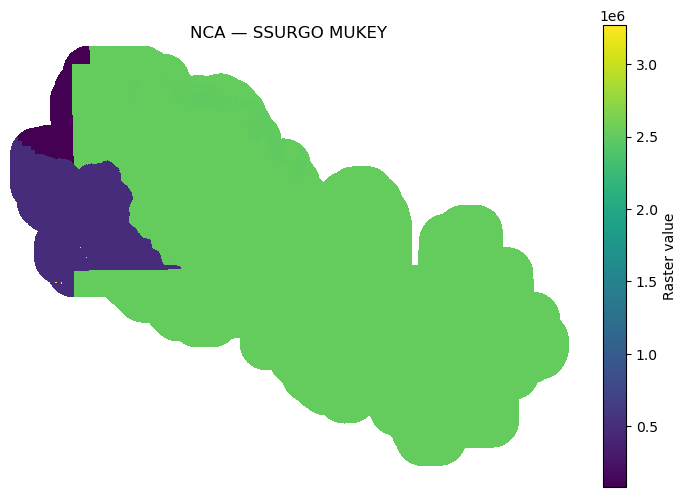


------------------------------------------------------------------------
NCA — Dominant ESD Site Code
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_esd_site_10m.tif
Shape: (7857, 10435)
NoData: 127.0
Min: 1.0
Max: 23.0
Unique valid values: 23
First values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


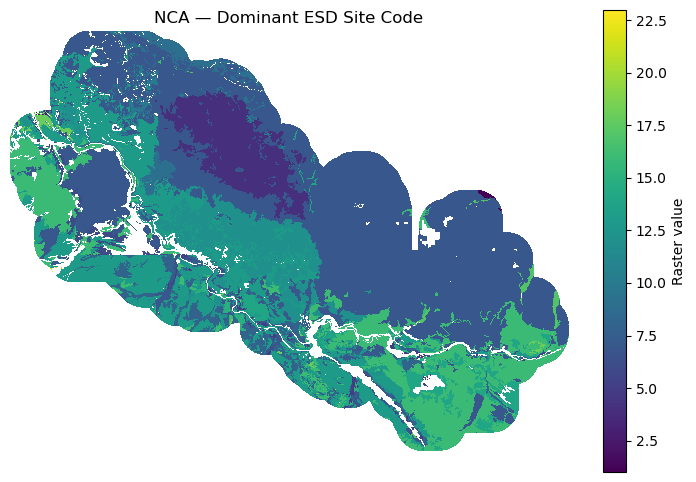


------------------------------------------------------------------------
NCA — Dominant Component Percent
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_component_pct_10m.tif
Shape: (7857, 10435)
NoData: 127.0
Min: 30.0
Max: 100.0


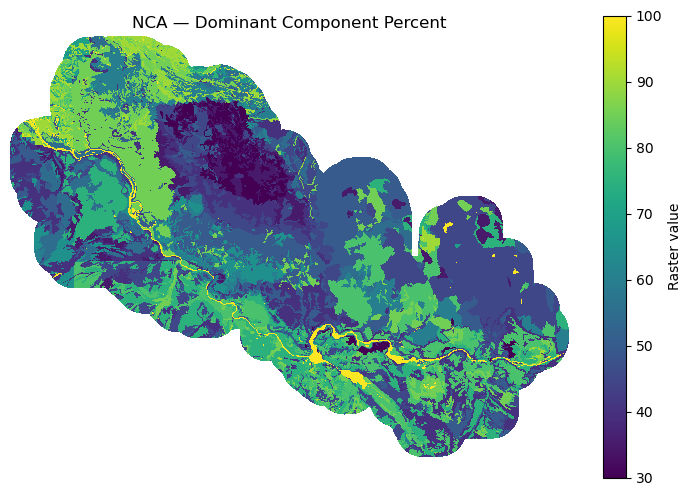


------------------------------------------------------------------------
NCA — Has Matched ESD
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_has_matched_esd_10m.tif
Shape: (7857, 10435)
NoData: 15.0
Min: 0.0
Max: 1.0
Unique valid values: 2
First values: [0. 1.]


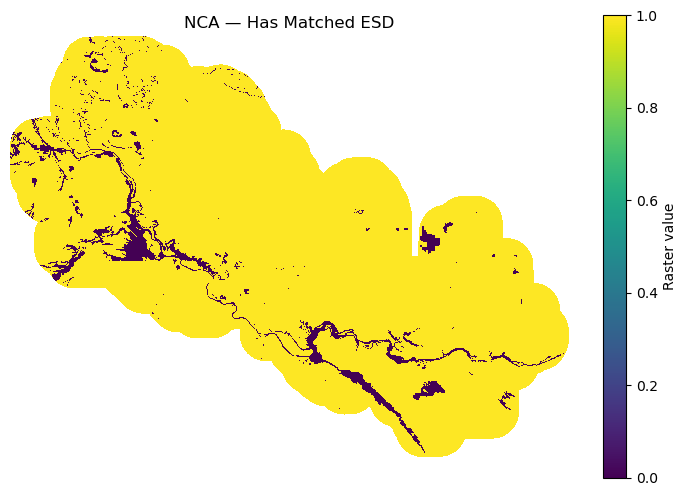


RCEW raster displays

------------------------------------------------------------------------
RCEW — SSURGO MUKEY
------------------------------------------------------------------------
Path: A:\RCEW_DATA\Ancillary_Data\SSURGO\GeoTIFF\RCEW_ssurgo_mukey_10m.tif
Shape: (2800, 1393)
NoData: 16.0
No valid pixels to display.

------------------------------------------------------------------------
RCEW — Dominant ESD Site Code
------------------------------------------------------------------------
Path: A:\RCEW_DATA\Ancillary_Data\SSURGO\GeoTIFF\RCEW_dominant_esd_site_10m.tif
Shape: (2800, 1393)
NoData: 0.0
Min: 1.0
Max: 14.0
Unique valid values: 14
First values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14.]


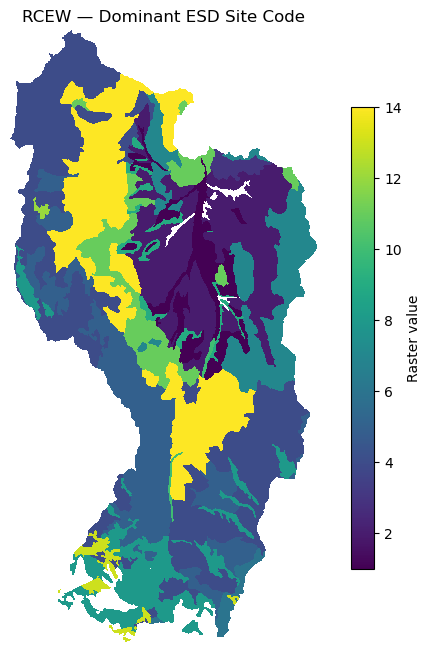


------------------------------------------------------------------------
RCEW — Dominant Component Percent
------------------------------------------------------------------------
Path: A:\RCEW_DATA\Ancillary_Data\SSURGO\GeoTIFF\RCEW_dominant_component_pct_10m.tif
Shape: (2800, 1393)
NoData: 127.0
Min: 30.0
Max: 100.0


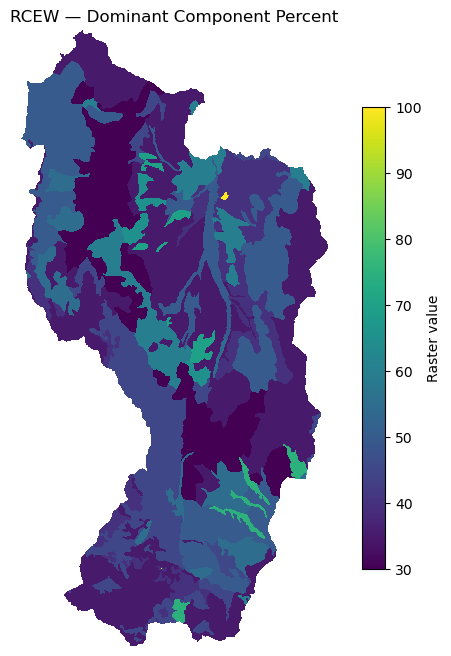


------------------------------------------------------------------------
RCEW — Has Matched ESD
------------------------------------------------------------------------
Path: A:\RCEW_DATA\Ancillary_Data\SSURGO\GeoTIFF\RCEW_has_matched_esd_10m.tif
Shape: (2800, 1393)
NoData: 15.0
Min: 0.0
Max: 1.0
Unique valid values: 2
First values: [0. 1.]


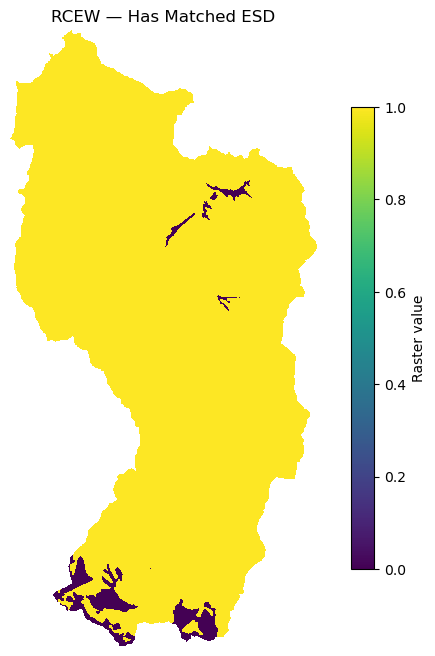

In [26]:
# ============================================================
# DISPLAY / PRINT EXPORTED SSURGO GEOTIFFS
# ============================================================
# Displays:
#   {AOI}_ssurgo_mukey_10m.tif
#   {AOI}_dominant_esd_site_10m.tif
#   {AOI}_dominant_component_pct_10m.tif
#   {AOI}_has_matched_esd_10m.tif
#
# Notes:
#   - MUKEY and ESD site rasters are categorical.
#   - Component percent is continuous.
#   - Has matched ESD should be binary: 0/1.
# ============================================================

import arcpy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def raster_to_array_for_plot(raster_path, nodata_to_nan=True):
    """
    Read raster to NumPy array for plotting.
    Converts NoData to NaN when possible.
    """
    raster_path = str(raster_path)
    r = arcpy.Raster(raster_path)

    arr = arcpy.RasterToNumPyArray(raster_path)

    # Handle multiband defensively.
    if arr.ndim == 3:
        arr = arr[0, :, :]

    nodata = r.noDataValue

    arr = arr.astype("float64")

    if nodata_to_nan and nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, nodata


def plot_raster(
    raster_path,
    title,
    categorical=True,
    max_unique_for_categories=80,
    figsize=(9, 8)
):
    """
    Display a raster with matplotlib.

    categorical=True:
      Uses nearest-neighbor display and reports unique value count.
      If the raster has many categories, the colorbar is still numeric.

    categorical=False:
      Uses continuous display.
    """
    raster_path = Path(raster_path)

    if not raster_path.exists() and not arcpy.Exists(str(raster_path)):
        print("Missing:", raster_path)
        return

    arr, nodata = raster_to_array_for_plot(raster_path)

    valid = arr[~np.isnan(arr)]

    print("\n" + "-" * 72)
    print(title)
    print("-" * 72)
    print("Path:", raster_path)
    print("Shape:", arr.shape)
    print("NoData:", nodata)

    if valid.size == 0:
        print("No valid pixels to display.")
        return

    print("Min:", np.nanmin(arr))
    print("Max:", np.nanmax(arr))

    if categorical:
        unique_vals = np.unique(valid)
        print("Unique valid values:", len(unique_vals))
        print("First values:", unique_vals[:20])

    plt.figure(figsize=figsize)

    if categorical:
        im = plt.imshow(arr, interpolation="nearest")
    else:
        im = plt.imshow(arr, interpolation="nearest")

    plt.title(title)
    plt.axis("off")
    cbar = plt.colorbar(im, shrink=0.75)
    cbar.set_label("Raster value")
    plt.show()


for aoi_name, cfg in AOIS.items():
    tif_dir = cfg["ssurgo_dir"] / "GeoTIFF"

    tifs = {
        "SSURGO MUKEY": {
            "path": tif_dir / f"{aoi_name}_ssurgo_mukey_10m.tif",
            "categorical": True,
        },
        "Dominant ESD Site Code": {
            "path": tif_dir / f"{aoi_name}_dominant_esd_site_10m.tif",
            "categorical": True,
        },
        "Dominant Component Percent": {
            "path": tif_dir / f"{aoi_name}_dominant_component_pct_10m.tif",
            "categorical": False,
        },
        "Has Matched ESD": {
            "path": tif_dir / f"{aoi_name}_has_matched_esd_10m.tif",
            "categorical": True,
        },
    }

    print("\n" + "=" * 80)
    print(f"{aoi_name} raster displays")
    print("=" * 80)

    for label, info in tifs.items():
        plot_raster(
            raster_path=info["path"],
            title=f"{aoi_name} — {label}",
            categorical=info["categorical"]
        )


------------------------------------------------------------------------
NCA — SSURGO MUKEY, categorical display
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_ssurgo_mukey_10m.tif
Shape: (7857, 10435)
Original min: 80720.0
Original max: 3270930.0
Unique categories: 387


C:\Users\scottfordham\AppData\Local\Temp\ipykernel_14664\2567183259.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap("tab20", 20)


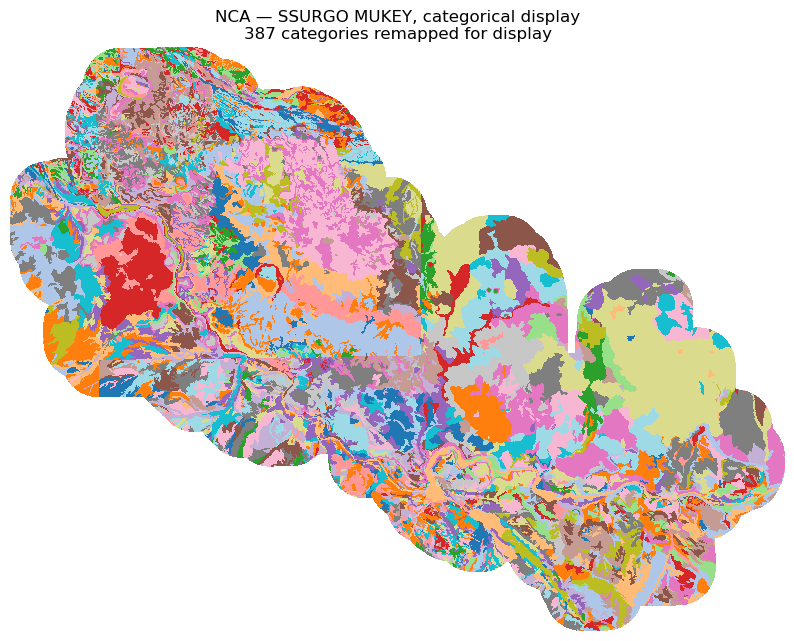


------------------------------------------------------------------------
NCA — Dominant ESD Site Code, categorical display
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_esd_site_10m.tif
Shape: (7857, 10435)
Original min: 1.0
Original max: 23.0
Unique categories: 23


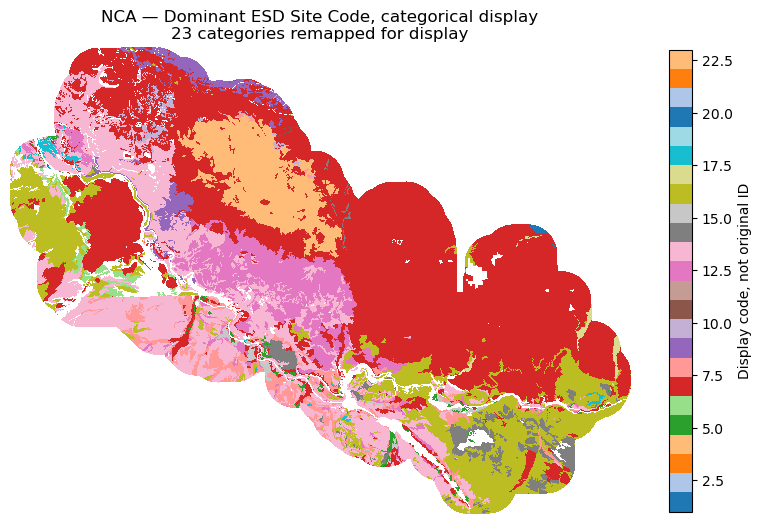


------------------------------------------------------------------------
NCA — Dominant Component Percent
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_dominant_component_pct_10m.tif
Shape: (7857, 10435)
Min: 30.0
Max: 100.0
Mean: 59.84544953841806


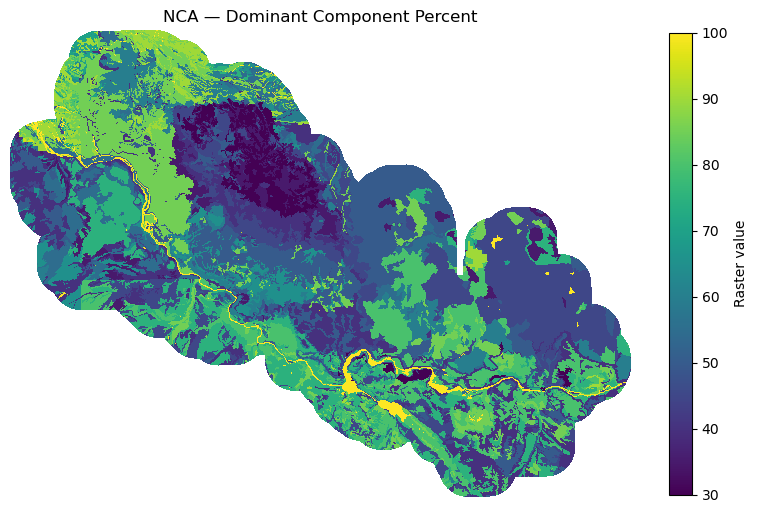


------------------------------------------------------------------------
NCA — Has Matched ESD
------------------------------------------------------------------------
Path: C:\NCA_DATA\Ancillary_Data\SSURGO\GeoTIFF\NCA_has_matched_esd_10m.tif
Shape: (7857, 10435)
Value 0.0: 2466304 pixels
Value 1.0: 42074650 pixels


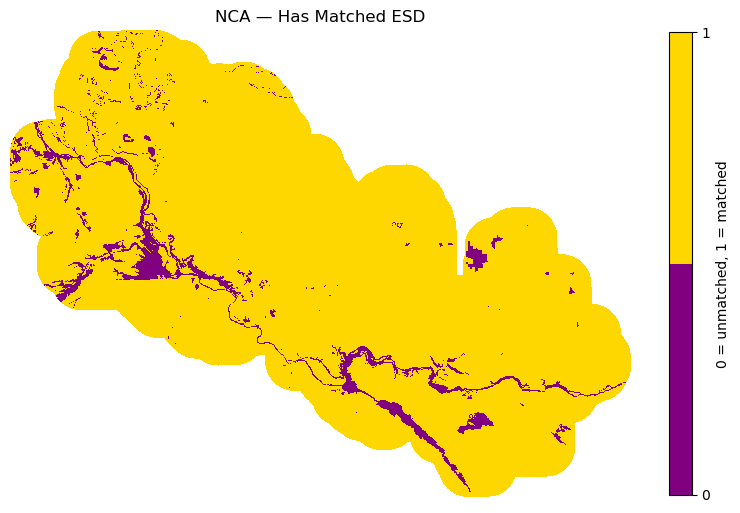


MUKEY display lookup example:
display 1 -> MUKEY 80720
display 2 -> MUKEY 80723
display 3 -> MUKEY 80724
display 4 -> MUKEY 80725
display 5 -> MUKEY 80726
display 6 -> MUKEY 80730
display 7 -> MUKEY 80731
display 8 -> MUKEY 80732
display 9 -> MUKEY 80733
display 10 -> MUKEY 80734
display 11 -> MUKEY 80735
display 12 -> MUKEY 80736
display 13 -> MUKEY 80737
display 14 -> MUKEY 80739
display 15 -> MUKEY 80745
display 16 -> MUKEY 80747
display 17 -> MUKEY 80753
display 18 -> MUKEY 80754
display 19 -> MUKEY 80755
display 20 -> MUKEY 80756

ESD site-code display lookup:
display 1 -> ESD_SITE_CODE 1
display 2 -> ESD_SITE_CODE 2
display 3 -> ESD_SITE_CODE 3
display 4 -> ESD_SITE_CODE 4
display 5 -> ESD_SITE_CODE 5
display 6 -> ESD_SITE_CODE 6
display 7 -> ESD_SITE_CODE 7
display 8 -> ESD_SITE_CODE 8
display 9 -> ESD_SITE_CODE 9
display 10 -> ESD_SITE_CODE 10
display 11 -> ESD_SITE_CODE 11
display 12 -> ESD_SITE_CODE 12
display 13 -> ESD_SITE_CODE 13
display 14 -> ESD_SITE_CODE 14
display 15 

In [27]:
# ============================================================
# NCA-ONLY: BETTER CATEGORICAL DISPLAY FOR SSURGO / ESD TIFS
# ============================================================
# This does NOT rewrite the rasters.
# It only remaps large categorical IDs to compact display codes
# so the maps are visually interpretable.
# ============================================================

import arcpy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm


NCA_TIF_DIR = AOIS["NCA"]["ssurgo_dir"] / "GeoTIFF"

NCA_TIFS = {
    "SSURGO MUKEY": NCA_TIF_DIR / "NCA_ssurgo_mukey_10m.tif",
    "Dominant ESD Site Code": NCA_TIF_DIR / "NCA_dominant_esd_site_10m.tif",
    "Dominant Component Percent": NCA_TIF_DIR / "NCA_dominant_component_pct_10m.tif",
    "Has Matched ESD": NCA_TIF_DIR / "NCA_has_matched_esd_10m.tif",
}


def read_raster_array(path):
    r = arcpy.Raster(str(path))
    arr = arcpy.RasterToNumPyArray(str(path))

    if arr.ndim == 3:
        arr = arr[0, :, :]

    arr = arr.astype("float64")
    nodata = r.noDataValue

    if nodata is not None:
        arr[arr == nodata] = np.nan

    return arr, nodata


def remap_categories_for_display(arr):
    """
    Convert arbitrary categorical raster values into compact 1..N codes.
    Returns:
      display_arr
      code_lookup: display_code -> original_value
    """
    valid = arr[~np.isnan(arr)]
    unique_vals = np.unique(valid)

    value_to_code = {
        val: idx + 1
        for idx, val in enumerate(unique_vals)
    }

    display = np.full(arr.shape, np.nan, dtype="float64")

    for val, code in value_to_code.items():
        display[arr == val] = code

    code_lookup = {
        code: val
        for val, code in value_to_code.items()
    }

    return display, code_lookup


def plot_categorical_compact(path, title, show_colorbar=False):
    arr, nodata = read_raster_array(path)
    display, code_lookup = remap_categories_for_display(arr)

    n_cat = len(code_lookup)

    print("\n" + "-" * 72)
    print(title)
    print("-" * 72)
    print("Path:", path)
    print("Shape:", arr.shape)
    print("Original min:", np.nanmin(arr))
    print("Original max:", np.nanmax(arr))
    print("Unique categories:", n_cat)

    # Tab20 repeated is enough for visual QA. Values are categorical,
    # so colors have no ordinal meaning.
    base = plt.cm.get_cmap("tab20", 20)
    colors = [base(i % 20) for i in range(n_cat + 1)]
    cmap = ListedColormap(colors)
    cmap.set_bad("white")

    plt.figure(figsize=(10, 8))
    im = plt.imshow(display, cmap=cmap, interpolation="nearest")
    plt.title(f"{title}\n{n_cat} categories remapped for display")
    plt.axis("off")

    if show_colorbar and n_cat <= 30:
        cbar = plt.colorbar(im, shrink=0.75)
        cbar.set_label("Display code, not original ID")

    plt.show()

    return code_lookup


def plot_continuous(path, title, vmin=None, vmax=None):
    arr, nodata = read_raster_array(path)

    print("\n" + "-" * 72)
    print(title)
    print("-" * 72)
    print("Path:", path)
    print("Shape:", arr.shape)
    print("Min:", np.nanmin(arr))
    print("Max:", np.nanmax(arr))
    print("Mean:", np.nanmean(arr))

    plt.figure(figsize=(10, 8))
    im = plt.imshow(arr, interpolation="nearest", vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    cbar = plt.colorbar(im, shrink=0.75)
    cbar.set_label("Raster value")
    plt.show()


def plot_binary(path, title):
    arr, nodata = read_raster_array(path)

    print("\n" + "-" * 72)
    print(title)
    print("-" * 72)
    print("Path:", path)
    print("Shape:", arr.shape)
    vals, counts = np.unique(arr[~np.isnan(arr)], return_counts=True)
    for v, c in zip(vals, counts):
        print(f"Value {v}: {c} pixels")

    cmap = ListedColormap(["purple", "gold"])
    cmap.set_bad("white")

    plt.figure(figsize=(10, 8))
    im = plt.imshow(arr, cmap=cmap, interpolation="nearest", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    cbar = plt.colorbar(im, shrink=0.75, ticks=[0, 1])
    cbar.set_label("0 = unmatched, 1 = matched")
    plt.show()


# ------------------------------------------------------------
# Plot NCA rasters
# ------------------------------------------------------------

mukey_lookup = plot_categorical_compact(
    NCA_TIFS["SSURGO MUKEY"],
    "NCA — SSURGO MUKEY, categorical display",
    show_colorbar=False
)

esd_lookup = plot_categorical_compact(
    NCA_TIFS["Dominant ESD Site Code"],
    "NCA — Dominant ESD Site Code, categorical display",
    show_colorbar=True
)

plot_continuous(
    NCA_TIFS["Dominant Component Percent"],
    "NCA — Dominant Component Percent",
    vmin=30,
    vmax=100
)

plot_binary(
    NCA_TIFS["Has Matched ESD"],
    "NCA — Has Matched ESD"
)

print("\nMUKEY display lookup example:")
for code, original in list(mukey_lookup.items())[:20]:
    print(f"display {code} -> MUKEY {int(original)}")

print("\nESD site-code display lookup:")
for code, original in esd_lookup.items():
    print(f"display {code} -> ESD_SITE_CODE {int(original)}")